# Advanced Frog Species Prediction Model
## Using TerraClimate Variables for Binary Classification

This notebook builds a machine learning classification model to predict frog species presence based on TerraClimate climate variables. The model uses advanced feature engineering, multiple algorithms, and proper cross-validation to achieve high F1 Score performance.

## Section 1: Import Required Libraries

Import necessary libraries for data science, machine learning, and data manipulation.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import joblib
import os

# Machine Learning
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GroupKFold, cross_val_score, cross_validate,
 )
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    precision_score, recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans

# Gradient boosting libraries

import lightgbm as lgb
import xgboost as xgb
import optuna

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    CatBoostClassifier = None
    CATBOOST_AVAILABLE = False
    print("CatBoost is not installed yet. The CatBoost blend block will be skipped unless you install it.")

# For climate data
import xarray as xr
import rasterio

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Runtime profile controls (set QUICK_MODE=True for faster experiments).
QUICK_MODE = False
LGB_OPTUNA_TRIALS = 80 if QUICK_MODE else 150
XGB_OPTUNA_TRIALS = 80 if QUICK_MODE else 150
CAT_OPTUNA_TRIALS = 30 if QUICK_MODE else 60
ENSEMBLE_SEEDS = [42, 52] if QUICK_MODE else [42, 52, 62, 72]

# GPU/CPU auto-selection (keeps the notebook portable across machines)
def _detect_lgbm_gpu() -> bool:
    try:
        rng = np.random.RandomState(42)
        X_small = rng.rand(50, 5)
        y_small = rng.randint(0, 2, size=50)

        m = lgb.LGBMClassifier(
            n_estimators=1,
            max_depth=2,
            num_leaves=8,
            learning_rate=0.1,
            subsample=1.0,
            colsample_bytree=1.0,
            device_type='gpu',
            random_state=42,
            verbose=-1,
            n_jobs=1,
        )
        m.fit(X_small, y_small)
        return True
    except Exception:
        return False


def _detect_xgb_cuda() -> bool:
    try:
        rng = np.random.RandomState(42)
        X_small = rng.rand(50, 5)
        y_small = rng.randint(0, 2, size=50)

        m = xgb.XGBClassifier(
            n_estimators=1,
            max_depth=2,
            learning_rate=0.1,
            subsample=1.0,
            colsample_bytree=1.0,
            tree_method='hist',
            device='cuda',
            random_state=42,
            verbosity=0,
            n_jobs=1,
            eval_metric='logloss',
        )
        m.fit(X_small, y_small)
        return True
    except Exception:
        return False


LGB_DEVICE_TYPE = 'gpu' if _detect_lgbm_gpu() else 'cpu'
XGB_DEVICE = 'cuda' if _detect_xgb_cuda() else 'cpu'

print("All libraries imported successfully!")
print(f"CatBoost available: {CATBOOST_AVAILABLE}")
print(f"LightGBM device_type: {LGB_DEVICE_TYPE}")
print(f"XGBoost device: {XGB_DEVICE}")
print(f"QUICK_MODE: {QUICK_MODE}")
print(f"Trials -> LGB:{LGB_OPTUNA_TRIALS}, XGB:{XGB_OPTUNA_TRIALS}, CAT:{CAT_OPTUNA_TRIALS}")
print(f"Ensemble seeds: {ENSEMBLE_SEEDS}")

## Section 2: Load and Explore the Data

Load the training and test datasets from CSV files and understand their structure.

In [ ]:
# Load training and test data
train_data = pd.read_csv('Training_Data.csv')
test_data = pd.read_csv('Test.csv')

print("Training Data Shape:", train_data.shape)
print("\nTraining Data Info:")
print(train_data.head())
print("\nTarget Distribution:")
print(train_data['Occurrence Status'].value_counts())
print("\nClass Balance:")
print(train_data['Occurrence Status'].value_counts(normalize=True))

print("\n" + "="*50)
print("Test Data Shape:", test_data.shape)
print("Test Data Info:")
print(test_data.head())

Training Data Shape: (6312, 4)

Training Data Info:
             ID   Latitude   Longitude  Occurrence Status
0  ID_TR_957A5A -34.027900  150.771000                  1
1  ID_TR_55E0AF -34.821595  147.193697                  1
2  ID_TR_7AC931 -36.617759  146.882941                  0
3  ID_TR_7D3CE4 -37.470900  144.744000                  1
4  ID_TR_02F669 -38.400153  145.018560                  1

Target Distribution:
Occurrence Status
1    3792
0    2520
Name: count, dtype: int64

Class Balance:
Occurrence Status
1    0.60076
0    0.39924
Name: proportion, dtype: float64

Test Data Shape: (2000, 3)
Test Data Info:
             ID   Latitude   Longitude
0  ID_TS_54240C -33.121788  150.320746
1  ID_TS_EF9635 -36.592011  148.172262
2  ID_TS_4E63E6 -35.455100  146.693465
3  ID_TS_FDAB8E -33.076261  149.547177
4  ID_TS_E00D49 -35.529729  146.627272


## Section 3: Extract TerraClimate Variables

Define a function to extract TerraClimate climate variables from GeoTIFF files using lat/lon coordinates.

In [ ]:
def extract_climate_features(tiff_path, csv_df, band_names):
    """
    Fast extraction of ALL climate bands from the GeoTIFF using rasterio sampling.
    Reads band_names from band_names.json generated by TerraClimate.ipynb.
    """
    with rasterio.open(tiff_path) as dataset:
        available_band_count = dataset.count
        usable_band_names = band_names[:available_band_count]
        if len(band_names) > available_band_count:
            print(
                f"Warning: GeoTIFF has only {available_band_count} bands but {len(band_names)} names were supplied. "
                "Truncating to available bands."
            )

        coords = list(zip(csv_df["Longitude"].values, csv_df["Latitude"].values))
        sampled = np.array(list(dataset.sample(coords)), dtype=np.float32)

    extracted = pd.DataFrame(sampled, columns=usable_band_names)
    extracted = extracted.replace([np.inf, -np.inf], np.nan)
    return extracted


# Load band names from JSON (generated by TerraClimate.ipynb)
tiff_path = 'TerraClimate_output.tiff'
band_names_file = 'band_names.json'

if os.path.exists(tiff_path) and os.path.exists(band_names_file):
    with open(band_names_file) as f:
        band_names = json.load(f)
    print(f"GeoTIFF found with {len(band_names)} bands: {band_names}")

    train_climate = extract_climate_features(tiff_path, train_data, band_names)
    test_climate = extract_climate_features(tiff_path, test_data, band_names)

    print(f"\nTrain climate shape: {train_climate.shape}")
    print(f"Test climate shape:  {test_climate.shape}")
    print(train_climate.describe())
elif os.path.exists(tiff_path):
    with rasterio.open(tiff_path) as src:
        n_bands = src.count
    band_names = [f"band_{i}" for i in range(1, n_bands + 1)]
    print(f"No band_names.json found. Reading {n_bands} bands with generic names.")

    train_climate = extract_climate_features(tiff_path, train_data, band_names)
    test_climate = extract_climate_features(tiff_path, test_data, band_names)
else:
    print("ERROR: TerraClimate_output.tiff not found!")
    print("Please run TerraClimate.ipynb first to generate the GeoTIFF.")
    train_climate = pd.DataFrame()
    test_climate = pd.DataFrame()

GeoTIFF found with 187 bands: ['aet_median', 'def_median', 'pdsi_median', 'pet_median', 'ppt_median', 'q_median', 'soil_median', 'srad_median', 'swe_median', 'tmax_median', 'tmin_median', 'vap_median', 'vpd_median', 'ws_median', 'aet_std', 'def_std', 'pdsi_std', 'pet_std', 'ppt_std', 'q_std', 'soil_std', 'srad_std', 'swe_std', 'tmax_std', 'tmin_std', 'vap_std', 'vpd_std', 'ws_std', 'ppt_wet_median', 'soil_wet_median', 'aet_wet_median', 'pet_wet_median', 'tmax_wet_median', 'tmin_wet_median', 'vpd_wet_median', 'vap_wet_median', 'ws_wet_median', 'ppt_dry_median', 'soil_dry_median', 'aet_dry_median', 'pet_dry_median', 'tmax_dry_median', 'tmin_dry_median', 'vpd_dry_median', 'vap_dry_median', 'ws_dry_median', 'ppt_wet_std', 'soil_wet_std', 'aet_wet_std', 'pet_wet_std', 'tmax_wet_std', 'tmin_wet_std', 'vpd_wet_std', 'vap_wet_std', 'ws_wet_std', 'ppt_dry_std', 'soil_dry_std', 'aet_dry_std', 'pet_dry_std', 'tmax_dry_std', 'tmin_dry_std', 'vpd_dry_std', 'vap_dry_std', 'ws_dry_std', 'ppt_q1_media

## Section 4: Preprocess and Engineer Features

Combine climate features with ground truth data, handle missing values, and prepare features for modeling.

In [ ]:
def create_combined_dataset(climate_df, ground_df, include_coords=True):
    """Combine climate features with ground truth data, optionally keep lat/lon as features."""
    combined = pd.concat([ground_df.reset_index(drop=True), climate_df.reset_index(drop=True)], axis=1)

    # Fill missing climate values with column median
    numeric_cols = combined.select_dtypes(include=[np.number]).columns
    combined[numeric_cols] = combined[numeric_cols].fillna(combined[numeric_cols].median())

    if not include_coords:
        combined = combined.drop(columns=['Latitude', 'Longitude'], errors='ignore')

    return combined


# Build combined datasets — KEEP lat/lon as features (geographic position is predictive)
if len(train_climate) > 0:
    X_train_combined = create_combined_dataset(train_climate, train_data, include_coords=True)
    X_test_combined = create_combined_dataset(test_climate, test_data, include_coords=True)
else:
    X_train_combined = train_data.copy()
    X_test_combined = test_data.copy()

print("Combined Training Data Shape:", X_train_combined.shape)
print("Columns:", X_train_combined.columns.tolist())

Combined Training Data Shape: (6312, 191)
Columns: ['ID', 'Latitude', 'Longitude', 'Occurrence Status', 'aet_median', 'def_median', 'pdsi_median', 'pet_median', 'ppt_median', 'q_median', 'soil_median', 'srad_median', 'swe_median', 'tmax_median', 'tmin_median', 'vap_median', 'vpd_median', 'ws_median', 'aet_std', 'def_std', 'pdsi_std', 'pet_std', 'ppt_std', 'q_std', 'soil_std', 'srad_std', 'swe_std', 'tmax_std', 'tmin_std', 'vap_std', 'vpd_std', 'ws_std', 'ppt_wet_median', 'soil_wet_median', 'aet_wet_median', 'pet_wet_median', 'tmax_wet_median', 'tmin_wet_median', 'vpd_wet_median', 'vap_wet_median', 'ws_wet_median', 'ppt_dry_median', 'soil_dry_median', 'aet_dry_median', 'pet_dry_median', 'tmax_dry_median', 'tmin_dry_median', 'vpd_dry_median', 'vap_dry_median', 'ws_dry_median', 'ppt_wet_std', 'soil_wet_std', 'aet_wet_std', 'pet_wet_std', 'tmax_wet_std', 'tmin_wet_std', 'vpd_wet_std', 'vap_wet_std', 'ws_wet_std', 'ppt_dry_std', 'soil_dry_std', 'aet_dry_std', 'pet_dry_std', 'tmax_dry_std', 

In [ ]:
# Prepare X and y — include Latitude/Longitude as features, exclude ID and target
exclude_cols = ['ID', 'Occurrence Status']
feature_cols = [c for c in X_train_combined.columns if c not in exclude_cols]

X = X_train_combined[feature_cols].copy()
y = X_train_combined['Occurrence Status'].copy()

test_ids = X_test_combined['ID'].copy()
X_test_final = X_test_combined[feature_cols].copy()

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Training: {X.shape}, Test: {X_test_final.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Imbalance ratio: {y.value_counts()[0] / y.value_counts()[1]:.2f}:1")

Features (189): ['Latitude', 'Longitude', 'aet_median', 'def_median', 'pdsi_median', 'pet_median', 'ppt_median', 'q_median', 'soil_median', 'srad_median', 'swe_median', 'tmax_median', 'tmin_median', 'vap_median', 'vpd_median', 'ws_median', 'aet_std', 'def_std', 'pdsi_std', 'pet_std', 'ppt_std', 'q_std', 'soil_std', 'srad_std', 'swe_std', 'tmax_std', 'tmin_std', 'vap_std', 'vpd_std', 'ws_std', 'ppt_wet_median', 'soil_wet_median', 'aet_wet_median', 'pet_wet_median', 'tmax_wet_median', 'tmin_wet_median', 'vpd_wet_median', 'vap_wet_median', 'ws_wet_median', 'ppt_dry_median', 'soil_dry_median', 'aet_dry_median', 'pet_dry_median', 'tmax_dry_median', 'tmin_dry_median', 'vpd_dry_median', 'vap_dry_median', 'ws_dry_median', 'ppt_wet_std', 'soil_wet_std', 'aet_wet_std', 'pet_wet_std', 'tmax_wet_std', 'tmin_wet_std', 'vpd_wet_std', 'vap_wet_std', 'ws_wet_std', 'ppt_dry_std', 'soil_dry_std', 'aet_dry_std', 'pet_dry_std', 'tmax_dry_std', 'tmin_dry_std', 'vpd_dry_std', 'vap_dry_std', 'ws_dry_std', 'p

## Section 4b: Spatial KNN Features

Compute occurrence-based spatial features using K-Nearest Neighbors with haversine distance. This captures the strong spatial autocorrelation of frog presence — nearby locations tend to have similar occurrence patterns.

In [ ]:
# ============================================================
# SPATIAL KNN FEATURES + FOLD-SAFE SPATIAL PRIORS (HELPERS)
# ============================================================
from sklearn.neighbors import BallTree

print("=" * 60)
print("SPATIAL FEATURE HELPERS READY")
print("=" * 60)

def compute_knn_features(ref_coords, ref_labels, query_coords, k_values=[3, 5, 10, 25, 50, 100],
                          exclude_self=False):
    """
    Compute KNN-based spatial features using haversine distance.
    """
    ref_arr = ref_coords[['Latitude', 'Longitude']].values
    query_arr = query_coords[['Latitude', 'Longitude']].values
    ref_rad = np.radians(ref_arr)
    query_rad = np.radians(query_arr)
    labels_arr = ref_labels.values if hasattr(ref_labels, 'values') else np.array(ref_labels)

    tree = BallTree(ref_rad, metric='haversine')
    max_k = max(k_values) + (1 if exclude_self else 0)
    max_k = min(max_k, len(ref_rad))
    distances, indices = tree.query(query_rad, k=max_k)

    offset = 1 if exclude_self else 0
    distances_km = distances * 6371.0

    features = {}
    for k in k_values:
        if k + offset > distances.shape[1]:
            continue
        k_dists = distances_km[:, offset:k+offset]
        k_idx = indices[:, offset:k+offset]
        k_labels = labels_arr[k_idx]

        features[f'knn_{k}_occ_mean'] = k_labels.mean(axis=1)
        features[f'knn_{k}_occ_std'] = k_labels.std(axis=1)
        features[f'knn_{k}_dist_mean'] = k_dists.mean(axis=1)
        features[f'knn_{k}_dist_min'] = k_dists[:, 0]
        features[f'knn_{k}_weighted_occ'] = np.average(
            k_labels, axis=1, weights=1.0 / (k_dists + 0.01)
        )

    for label_val, label_name in [(1, 'pos'), (0, 'neg')]:
        mask = labels_arr == label_val
        if mask.sum() < 2:
            continue
        sub_rad = ref_rad[mask]
        sub_tree = BallTree(sub_rad, metric='haversine')

        if exclude_self:
            sub_dist, _ = sub_tree.query(query_rad, k=min(2, mask.sum()))
            is_same = np.zeros(len(query_rad), dtype=bool)
            if len(labels_arr) == len(query_rad):
                is_same = labels_arr == label_val
            features[f'dist_nearest_{label_name}_km'] = np.where(
                is_same,
                sub_dist[:, min(1, sub_dist.shape[1]-1)] * 6371.0,
                sub_dist[:, 0] * 6371.0
            )
        else:
            sub_dist, _ = sub_tree.query(query_rad, k=1)
            features[f'dist_nearest_{label_name}_km'] = sub_dist[:, 0] * 6371.0

    if 'dist_nearest_pos_km' in features and 'dist_nearest_neg_km' in features:
        features['dist_ratio_pos_neg'] = (
            features['dist_nearest_pos_km'] / (features['dist_nearest_neg_km'] + 0.01)
        )
        features['dist_diff_pos_neg'] = (
            features['dist_nearest_pos_km'] - features['dist_nearest_neg_km']
        )

    return pd.DataFrame(features)


def add_spatial_prior_features(train_df, train_labels, query_df, cv_splits=5, random_state=42, n_clusters=40):
    """
    Build fold-safe train priors (OOF on train_df) and mapped priors on query_df from full train_df.
    """
    train_coords = train_df[['Latitude', 'Longitude']].reset_index(drop=True).copy()
    query_coords = query_df[['Latitude', 'Longitude']].reset_index(drop=True).copy()
    y_arr = pd.Series(train_labels).reset_index(drop=True)
    global_rate = float(y_arr.mean())

    def build_meta(coords_df, clusterer=None):
        meta = pd.DataFrame(index=coords_df.index)
        meta['lat_bin_025'] = np.round(coords_df['Latitude'] / 0.25) * 0.25
        meta['lon_bin_025'] = np.round(coords_df['Longitude'] / 0.25) * 0.25
        meta['lat_bin_050'] = np.round(coords_df['Latitude'] / 0.50) * 0.50
        meta['lon_bin_050'] = np.round(coords_df['Longitude'] / 0.50) * 0.50
        meta['grid_025'] = meta['lat_bin_025'].astype(str) + '_' + meta['lon_bin_025'].astype(str)
        meta['grid_050'] = meta['lat_bin_050'].astype(str) + '_' + meta['lon_bin_050'].astype(str)
        if clusterer is not None:
            meta['cluster_id'] = clusterer.predict(coords_df[['Latitude', 'Longitude']])
        return meta

    derived_clusters = max(8, min(n_clusters, len(train_coords) // 120 if len(train_coords) // 120 > 0 else 8))
    clusterer = KMeans(n_clusters=derived_clusters, random_state=random_state, n_init=10)
    clusterer.fit(train_coords[['Latitude', 'Longitude']])

    train_meta = build_meta(train_coords, clusterer)
    query_meta = build_meta(query_coords, clusterer)

    prior_cols = ['grid_025', 'grid_050', 'cluster_id']
    train_prior = pd.DataFrame(index=train_meta.index)
    query_prior = pd.DataFrame(index=query_meta.index)

    skf_spatial = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    for tr_idx, va_idx in skf_spatial.split(train_coords, y_arr):
        fold_train = train_meta.iloc[tr_idx].copy()
        fold_train['target'] = y_arr.iloc[tr_idx].values
        fold_valid = train_meta.iloc[va_idx].copy()

        for col in prior_cols:
            agg = fold_train.groupby(col)['target'].agg(['mean', 'count'])
            train_prior.loc[va_idx, f'{col}_target_mean'] = fold_valid[col].map(agg['mean']).fillna(global_rate).values
            train_prior.loc[va_idx, f'{col}_target_count'] = fold_valid[col].map(agg['count']).fillna(0).values

    full_meta = train_meta.copy()
    full_meta['target'] = y_arr.values
    for col in prior_cols:
        agg = full_meta.groupby(col)['target'].agg(['mean', 'count'])
        query_prior[f'{col}_target_mean'] = query_meta[col].map(agg['mean']).fillna(global_rate).values
        query_prior[f'{col}_target_count'] = query_meta[col].map(agg['count']).fillna(0).values

    rename_map = {
        'grid_025_target_mean': 'spatial_prior_grid025',
        'grid_050_target_mean': 'spatial_prior_grid050',
        'cluster_id_target_mean': 'spatial_prior_cluster',
        'grid_025_target_count': 'spatial_density_grid025',
        'grid_050_target_count': 'spatial_density_grid050',
        'cluster_id_target_count': 'spatial_density_cluster',
    }
    train_prior = train_prior.rename(columns=rename_map)
    query_prior = query_prior.rename(columns=rename_map)

    for df in [train_prior, query_prior]:
        df['spatial_prior_mean'] = df[[
            'spatial_prior_grid025', 'spatial_prior_grid050', 'spatial_prior_cluster'
        ]].mean(axis=1)
        df['spatial_density_mean'] = np.log1p(df[[
            'spatial_density_grid025', 'spatial_density_grid050', 'spatial_density_cluster'
        ]].mean(axis=1))

    return train_prior.fillna(global_rate), query_prior.fillna(global_rate)


print("Spatial features are now computed later in split/fold-safe blocks to avoid leakage.")

COMPUTING SPATIAL FEATURES
Computing KNN features for training data (leave-one-out)...
Computing KNN features for test data...
Computing fold-safe spatial prior features...

KNN features added (34): ['knn_3_occ_mean', 'knn_3_occ_std', 'knn_3_dist_mean', 'knn_3_dist_min', 'knn_3_weighted_occ', 'knn_5_occ_mean', 'knn_5_occ_std', 'knn_5_dist_mean', 'knn_5_dist_min', 'knn_5_weighted_occ', 'knn_10_occ_mean', 'knn_10_occ_std', 'knn_10_dist_mean', 'knn_10_dist_min', 'knn_10_weighted_occ', 'knn_25_occ_mean', 'knn_25_occ_std', 'knn_25_dist_mean', 'knn_25_dist_min', 'knn_25_weighted_occ', 'knn_50_occ_mean', 'knn_50_occ_std', 'knn_50_dist_mean', 'knn_50_dist_min', 'knn_50_weighted_occ', 'knn_100_occ_mean', 'knn_100_occ_std', 'knn_100_dist_mean', 'knn_100_dist_min', 'knn_100_weighted_occ', 'dist_nearest_pos_km', 'dist_nearest_neg_km', 'dist_ratio_pos_neg', 'dist_diff_pos_neg']
Spatial prior features added (8): ['spatial_prior_grid025', 'spatial_density_grid025', 'spatial_prior_grid050', 'spatial_d

## Section 5: Split Data into Training and Validation Sets

Partition the training data into train and validation subsets using stratified split to maintain class balance.

In [ ]:
# Stratified train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Keep leakage-safe base copies (before any target-based spatial features are appended).
X_train_base = X_train.reset_index(drop=True).copy()
X_val_base = X_val.reset_index(drop=True).copy()
X_test_base = X_test_final.reset_index(drop=True).copy()
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

print(f"Train: {X_train.shape},  Val: {X_val.shape}")
print(f"Train dist:\n{y_train.value_counts(normalize=True)}")
print(f"Val dist:\n{y_val.value_counts(normalize=True)}")

print("\n" + "=" * 60)
print("ADDING SPLIT-SAFE SPATIAL FEATURES (TRAIN->VAL/TEST)")
print("=" * 60)

# KNN features from TRAIN labels only
train_knn = compute_knn_features(X_train_base, y_train, X_train_base, exclude_self=True)
val_knn = compute_knn_features(X_train_base, y_train, X_val_base, exclude_self=False)
test_knn = compute_knn_features(X_train_base, y_train, X_test_base, exclude_self=False)

# Spatial prior features: OOF for train, mapped from full-train for val/test
query_concat = pd.concat([X_val_base, X_test_base], axis=0).reset_index(drop=True)
train_spatial_prior, query_spatial_prior = add_spatial_prior_features(
    X_train_base, y_train, query_concat, cv_splits=5, random_state=42, n_clusters=40
)
val_spatial_prior = query_spatial_prior.iloc[:len(X_val_base)].reset_index(drop=True)
test_spatial_prior = query_spatial_prior.iloc[len(X_val_base):].reset_index(drop=True)

# Append spatial features
X_train = pd.concat([
    X_train_base.reset_index(drop=True),
    train_knn.reset_index(drop=True),
    train_spatial_prior.reset_index(drop=True)
], axis=1)
X_val = pd.concat([
    X_val_base.reset_index(drop=True),
    val_knn.reset_index(drop=True),
    val_spatial_prior.reset_index(drop=True)
], axis=1)
X_test_final = pd.concat([
    X_test_base.reset_index(drop=True),
    test_knn.reset_index(drop=True),
    test_spatial_prior.reset_index(drop=True)
], axis=1)

feature_cols = X_train.columns.tolist()
print(f"Split-safe feature count: {len(feature_cols)}")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test_final.shape}")

Train: (5049, 231),  Val: (1263, 231)
Train dist:
Occurrence Status
1    0.600713
0    0.399287
Name: proportion, dtype: float64
Val dist:
Occurrence Status
1    0.60095
0    0.39905
Name: proportion, dtype: float64


## Section 6: Feature Engineering

Create derived features from climate variables to improve model discrimination.

In [ ]:
def engineer_features(df, base_feature_cols):
    """Create derived features from climate, seasonal, quarterly, spatial, and KNN columns."""
    out = df.copy()

    excluded_prefixes = ('knn_', 'dist_', 'spatial_prior_', 'spatial_density_')
    climate_cols = [
        c for c in base_feature_cols
        if c not in ['Latitude', 'Longitude'] and not c.startswith(excluded_prefixes)
    ]
    median_cols = [c for c in climate_cols if c.endswith('_median')]
    std_cols = [c for c in climate_cols if c.endswith('_std')]

    def has_cols(*cols):
        return all(col in out.columns for col in cols)

    # 1. Aggregate statistics across climate features
    if len(climate_cols) >= 2:
        out['climate_mean'] = out[climate_cols].mean(axis=1)
        out['climate_std'] = out[climate_cols].std(axis=1)
        out['climate_range'] = out[climate_cols].max(axis=1) - out[climate_cols].min(axis=1)
        out['climate_cv'] = out['climate_std'] / (out['climate_mean'].abs() + 1e-8)
        out['climate_skew_proxy'] = out['climate_mean'] - out[climate_cols].median(axis=1)
    if len(std_cols) >= 2:
        out['climate_variability_mean'] = out[std_cols].mean(axis=1)
        out['climate_variability_max'] = out[std_cols].max(axis=1)

    # 2. Geography features
    if has_cols('Latitude', 'Longitude'):
        out['lat_lon_interaction'] = out['Latitude'] * out['Longitude']
        out['lat_abs'] = out['Latitude'].abs()
        out['lon_abs'] = out['Longitude'].abs()
        out['lat_sin'] = np.sin(np.radians(out['Latitude']))
        out['lat_cos'] = np.cos(np.radians(out['Latitude']))
        out['lon_sin'] = np.sin(np.radians(out['Longitude']))
        out['lon_cos'] = np.cos(np.radians(out['Longitude']))
        out['geo_radius'] = np.sqrt(out['Latitude'] ** 2 + out['Longitude'] ** 2)

    # 3. Variability relative to level
    for mc in median_cols:
        var_base = mc.replace('_median', '')
        sc = f"{var_base}_std"
        if sc in out.columns:
            out[f"{var_base}_cv"] = out[sc] / (out[mc].abs() + 1e-8)

    # 4. Domain-driven hydrology and temperature signals
    if has_cols('tmax_median', 'tmin_median'):
        out['temp_mean'] = (out['tmax_median'] + out['tmin_median']) / 2.0
        out['temp_range'] = out['tmax_median'] - out['tmin_median']
    if has_cols('tmax_std', 'tmin_std'):
        out['temp_range_std'] = out['tmax_std'] - out['tmin_std']
    if has_cols('ppt_median', 'pet_median'):
        out['water_balance'] = out['ppt_median'] - out['pet_median']
        out['aridity_ratio'] = out['pet_median'] / (out['ppt_median'].abs() + 1e-8)
    if has_cols('aet_median', 'pet_median'):
        out['aet_pet_ratio'] = out['aet_median'] / (out['pet_median'].abs() + 1e-8)
    if has_cols('aet_median', 'ppt_median'):
        out['aet_ppt_ratio'] = out['aet_median'] / (out['ppt_median'].abs() + 1e-8)
    if has_cols('soil_median', 'ppt_median'):
        out['soil_ppt_ratio'] = out['soil_median'] / (out['ppt_median'].abs() + 1e-8)
    if has_cols('vap_median', 'vpd_median'):
        out['vap_vpd_gap'] = out['vap_median'] - out['vpd_median']
        out['vap_vpd_ratio'] = out['vap_median'] / (out['vpd_median'].abs() + 1e-8)
    if has_cols('srad_median', 'ws_median'):
        out['radiation_wind_interaction'] = out['srad_median'] * out['ws_median']
    if has_cols('srad_median', 'tmax_median', 'tmin_median'):
        temp_mean = (out['tmax_median'] + out['tmin_median']) / 2.0
        out['energy_temp_interaction'] = out['srad_median'] * temp_mean

    # 5. Seasonal wet/dry features (available after TerraClimate rerun)
    seasonal_pairs = [
        ('ppt', 'wet', 'dry'), ('soil', 'wet', 'dry'), ('aet', 'wet', 'dry'),
        ('pet', 'wet', 'dry'), ('tmax', 'wet', 'dry'), ('tmin', 'wet', 'dry'), ('vpd', 'wet', 'dry')
    ]
    for var, wet_name, dry_name in seasonal_pairs:
        wet_col = f'{var}_{wet_name}_median'
        dry_col = f'{var}_{dry_name}_median'
        if has_cols(wet_col, dry_col):
            out[f'{var}_season_gap'] = out[wet_col] - out[dry_col]
            out[f'{var}_season_ratio'] = out[wet_col] / (out[dry_col].abs() + 1e-8)

    # 6. Quarterly / monthly climate dynamics (used if new TerraClimate export is rerun)
    for base_var in ['ppt', 'soil', 'tmax', 'tmin', 'pet', 'aet', 'vpd']:
        q_cols = [f'{base_var}_q{q}_median' for q in range(1, 5) if f'{base_var}_q{q}_median' in out.columns]
        if len(q_cols) >= 2:
            out[f'{base_var}_quarter_range'] = out[q_cols].max(axis=1) - out[q_cols].min(axis=1)
            out[f'{base_var}_quarter_mean'] = out[q_cols].mean(axis=1)
            out[f'{base_var}_quarter_std'] = out[q_cols].std(axis=1)

        m_cols = [f'{base_var}_m{m:02d}_mean' for m in range(1, 13) if f'{base_var}_m{m:02d}_mean' in out.columns]
        if len(m_cols) >= 2:
            out[f'{base_var}_monthly_range'] = out[m_cols].max(axis=1) - out[m_cols].min(axis=1)
            out[f'{base_var}_monthly_std'] = out[m_cols].std(axis=1)

    # 6b. Bioclimatic cross-variable temperature extremes (WorldClim BIO analogs)
    tmax_q = sorted([c for c in out.columns if c.startswith('tmax_q') and c.endswith('_median')])
    tmin_q = sorted([c for c in out.columns if c.startswith('tmin_q') and c.endswith('_median')])
    if len(tmax_q) >= 2 and len(tmin_q) >= 2:
        out['bio7_temp_annual_range'] = out[tmax_q].max(axis=1) - out[tmin_q].min(axis=1)
        out['coldest_quarter_tmin']   = out[tmin_q].min(axis=1)
        out['warmest_quarter_tmax']   = out[tmax_q].max(axis=1)

    # 6c. Monthly precipitation extremes and intra-annual variability
    ppt_m = sorted([c for c in out.columns if c.startswith('ppt_m') and c.endswith('_mean')])
    if len(ppt_m) >= 2:
        out['ppt_wettest_month']  = out[ppt_m].max(axis=1)
        out['ppt_driest_month']   = out[ppt_m].min(axis=1)
        out['bio13_14_ppt_range'] = out['ppt_wettest_month'] - out['ppt_driest_month']
        out['bio15_ppt_cv']       = out[ppt_m].std(axis=1) / (out[ppt_m].mean(axis=1).abs() + 1e-8)
        out['ppt_max_min_ratio']  = out['ppt_wettest_month'] / (out['ppt_driest_month'] + 1e-8)

    # 6d. Extreme-event proxies from stored percentiles (p10/p90)
    if has_cols('ppt_p90', 'ppt_p10'):
        out['ppt_extreme_ratio'] = out['ppt_p90'] / (out['ppt_p10'] + 1e-8)
        out['ppt_extreme_range'] = out['ppt_p90'] - out['ppt_p10']
    if has_cols('tmax_p90', 'tmin_p10'):
        out['temp_extreme_range'] = out['tmax_p90'] - out['tmin_p10']
    if has_cols('vpd_p90', 'vpd_p10'):
        out['vpd_extreme_range'] = out['vpd_p90'] - out['vpd_p10']
    if has_cols('soil_p90', 'soil_p10'):
        out['soil_extreme_range'] = out['soil_p90'] - out['soil_p10']

    # 6e. Water-stress and heat-moisture interaction features
    if has_cols('def_median', 'aet_median'):
        out['moisture_stress_ratio'] = out['def_median'] / (out['aet_median'] + 1e-8)
    if has_cols('tmax_median', 'vpd_median'):
        out['heat_stress'] = out['tmax_median'] * out['vpd_median']
    if has_cols('ppt_median', 'tmax_median'):
        out['rain_heat_interaction'] = out['ppt_median'] * out['tmax_median']
    if has_cols('soil_median', 'vpd_median'):
        out['soil_vpd_interaction'] = out['soil_median'] * out['vpd_median']
    if has_cols('aet_median', 'vpd_median'):
        out['aet_vpd_stress'] = out['aet_median'] / (out['vpd_median'] + 1e-8)


    # 7. KNN summary features and spatial-climate interactions
    knn_occ_cols = [c for c in out.columns if c.startswith('knn_') and c.endswith('_occ_mean')]
    knn_dist_cols = [c for c in out.columns if c.startswith('knn_') and c.endswith('_dist_mean')]
    if knn_occ_cols:
        out['knn_occ_mean_avg'] = out[knn_occ_cols].mean(axis=1)
        out['knn_occ_mean_max'] = out[knn_occ_cols].max(axis=1)
    if knn_dist_cols:
        out['knn_dist_mean_avg'] = out[knn_dist_cols].mean(axis=1)
        out['knn_dist_mean_min'] = out[knn_dist_cols].min(axis=1)
    if has_cols('knn_25_occ_mean', 'ppt_median'):
        out['ppt_knn25_interaction'] = out['ppt_median'] * out['knn_25_occ_mean']
    if has_cols('knn_25_occ_mean', 'temp_range'):
        out['temp_range_knn25_interaction'] = out['temp_range'] * out['knn_25_occ_mean']
    if has_cols('dist_nearest_pos_km', 'dist_nearest_neg_km'):
        out['log_dist_ratio_pos_neg'] = np.log1p(out['dist_nearest_pos_km']) - np.log1p(out['dist_nearest_neg_km'])

    # 8. Spatial prior interactions
    if has_cols('spatial_prior_mean', 'ppt_median'):
        out['ppt_spatial_prior_interaction'] = out['ppt_median'] * out['spatial_prior_mean']
    if has_cols('spatial_prior_mean', 'soil_median'):
        out['soil_spatial_prior_interaction'] = out['soil_median'] * out['spatial_prior_mean']
    if has_cols('spatial_prior_mean', 'temp_range'):
        out['temp_spatial_prior_interaction'] = out['temp_range'] * out['spatial_prior_mean']
    if has_cols('spatial_density_mean', 'knn_occ_mean_avg'):
        out['density_knn_interaction'] = out['spatial_density_mean'] * out['knn_occ_mean_avg']

    # 9. Non-linear terms for high-signal variables
    priority_cols = [
        c for c in [
            'ppt_median', 'soil_median', 'temp_range', 'water_balance',
            'spatial_prior_mean', 'knn_occ_mean_avg', 'dist_ratio_pos_neg'
        ] if c in out.columns
    ]
    for col in priority_cols:
        out[f'{col}_sq'] = out[col] ** 2

    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.fillna(out.median(numeric_only=True))
    return out

# Apply feature engineering
X_train_eng = engineer_features(X_train, feature_cols)
X_val_eng = engineer_features(X_val, feature_cols)
X_test_eng = engineer_features(X_test_final, feature_cols)

eng_feature_cols = X_train_eng.columns.tolist()
print(f"Engineered feature count: {len(eng_feature_cols)}")
print(f"Sample features: {eng_feature_cols[:30]}")

Engineered feature count: 373
Sample features: ['Latitude', 'Longitude', 'aet_median', 'def_median', 'pdsi_median', 'pet_median', 'ppt_median', 'q_median', 'soil_median', 'srad_median', 'swe_median', 'tmax_median', 'tmin_median', 'vap_median', 'vpd_median', 'ws_median', 'aet_std', 'def_std', 'pdsi_std', 'pet_std', 'ppt_std', 'q_std', 'soil_std', 'srad_std', 'swe_std', 'tmax_std', 'tmin_std', 'vap_std', 'vpd_std', 'ws_std']


## Section 6b: Temporal Climate Signal Augmentation

Add lightweight time-pattern signals from monthly and quarterly climate columns (trend, seasonal contrasts, and wet-dry gaps). This is safe: it only creates features when those columns exist.

In [ ]:
# ============================================================
# TEMPORAL CLIMATE SIGNAL AUGMENTATION (SAFE / OPTIONAL)
# ============================================================
def add_temporal_climate_signals(df):
    out = df.copy()

    def _monthly_cols(base_var):
        cols = [f'{base_var}_m{m:02d}_mean' for m in range(1, 13)]
        return [c for c in cols if c in out.columns]

    month_idx = np.arange(1, 13, dtype=float)
    month_idx_centered = month_idx - month_idx.mean()
    month_denom = np.sum(month_idx_centered ** 2) + 1e-8

    for var in ['ppt', 'soil', 'tmax', 'tmin', 'pet', 'aet', 'vpd']:
        m_cols = _monthly_cols(var)
        if len(m_cols) == 12:
            mvals = out[m_cols].values.astype(float)
            m_mean = mvals.mean(axis=1, keepdims=True)
            slope_num = np.sum((mvals - m_mean) * month_idx_centered, axis=1)
            out[f'{var}_monthly_trend'] = slope_num / month_denom
            out[f'{var}_monthly_amp'] = mvals.max(axis=1) - mvals.min(axis=1)
            out[f'{var}_wet_dry_gap'] = (
                mvals[:, [10, 11, 0, 1]].mean(axis=1) - mvals[:, [5, 6, 7, 8]].mean(axis=1)
            )
            out[f'{var}_q1_q3_gap'] = (
                mvals[:, [0, 1, 2]].mean(axis=1) - mvals[:, [6, 7, 8]].mean(axis=1)
            )

        q_cols = [f'{var}_q{q}_median' for q in range(1, 5) if f'{var}_q{q}_median' in out.columns]
        if len(q_cols) == 4:
            qvals = out[q_cols].values.astype(float)
            out[f'{var}_quarter_trend'] = qvals[:, 3] - qvals[:, 0]
            out[f'{var}_quarter_amp'] = qvals.max(axis=1) - qvals.min(axis=1)

    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.fillna(out.median(numeric_only=True))
    return out


def prune_feature_space(X_train_df, X_val_df, X_test_df, variance_eps=1e-8, corr_cutoff=0.995, max_drop_ratio=0.35):
    """Prune near-constant and highly correlated features using training data only."""
    keep_protected = {'Latitude', 'Longitude'}
    cols = X_train_df.columns.tolist()

    # 1) Near-constant features
    near_constant = []
    for c in cols:
        if c in keep_protected:
            continue
        if X_train_df[c].nunique(dropna=False) <= 1 or float(X_train_df[c].std()) <= variance_eps:
            near_constant.append(c)

    # 2) Very high-correlation pairs
    candidate_cols = [c for c in cols if c not in near_constant and c not in keep_protected]
    corr = X_train_df[candidate_cols].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    to_drop_corr = []
    for col in upper.columns:
        high_corr = upper[col] > corr_cutoff
        if high_corr.any():
            to_drop_corr.append(col)

    # Cap total dropped columns to avoid over-pruning in one pass.
    max_drop = int(max_drop_ratio * len(cols))
    drop_all = near_constant + [c for c in to_drop_corr if c not in near_constant]
    if len(drop_all) > max_drop and max_drop > 0:
        drop_all = drop_all[:max_drop]

    keep_cols = [c for c in cols if c not in set(drop_all)]

    X_train_out = X_train_df[keep_cols].copy()
    X_val_out = X_val_df[keep_cols].copy()
    X_test_out = X_test_df[keep_cols].copy()

    stats = {
        'near_constant_dropped': len(near_constant),
        'high_corr_dropped': len([c for c in drop_all if c in to_drop_corr]),
        'total_dropped': len(drop_all),
        'kept': len(keep_cols),
    }
    return X_train_out, X_val_out, X_test_out, keep_cols, stats

n_before = len(X_train_eng.columns)
X_train_eng = add_temporal_climate_signals(X_train_eng)
X_val_eng = add_temporal_climate_signals(X_val_eng)
X_test_eng = add_temporal_climate_signals(X_test_eng)
n_after_temporal = len(X_train_eng.columns)

# Prune noisy/redundant features before expensive tuning.
X_train_eng, X_val_eng, X_test_eng, eng_feature_cols, prune_stats = prune_feature_space(
    X_train_eng, X_val_eng, X_test_eng, variance_eps=1e-8, corr_cutoff=0.995, max_drop_ratio=0.35
)
n_after_prune = len(eng_feature_cols)

print(f'Temporal signal features added: {n_after_temporal - n_before}')
print(f"Pruned near-constant: {prune_stats['near_constant_dropped']}")
print(f"Pruned high-correlation: {prune_stats['high_corr_dropped']}")
print(f"Feature count after pruning: {n_after_prune}")

# If imputed matrices already exist in memory, refresh them to stay consistent for later cells.
if 'X_train_imp' in globals() and 'X_val_imp' in globals():
    _temp_imputer = SimpleImputer(strategy='median')
    X_train_imp = pd.DataFrame(_temp_imputer.fit_transform(X_train_eng), columns=eng_feature_cols)
    X_val_imp = pd.DataFrame(_temp_imputer.transform(X_val_eng), columns=eng_feature_cols)
    print('Refreshed X_train_imp/X_val_imp with temporal+pruned features.')

Temporal signal features added: 38
Feature count now: 408
Refreshed X_train_imp/X_val_imp with temporal features.


In [ ]:
# ============================================================
# OPTUNA HYPERPARAMETER TUNING FOR LightGBM
# ============================================================
print("=" * 60)
print(f"OPTUNA: Tuning LightGBM with {LGB_OPTUNA_TRIALS} trials (5-fold CV, device_type={LGB_DEVICE_TYPE})")
print("=" * 60)

# NOTE:
# Running GPU training in parallel CV processes (n_jobs=-1) can crash the kernel on some setups.
# Keep CV single-process for stability.

# Impute once for Optuna loop
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_eng), columns=eng_feature_cols
)
X_val_imp = pd.DataFrame(
    imputer.transform(X_val_eng), columns=eng_feature_cols
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 250, 700),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'num_leaves': trial.suggest_int('num_leaves', 24, 160),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 60),
        'subsample': trial.suggest_float('subsample', 0.65, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.55, 0.95),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-6, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-6, 5.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.8, 3.0),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 0.2),
        'device_type': LGB_DEVICE_TYPE,
    }
    try:
        model = lgb.LGBMClassifier(**params, random_state=42, verbose=-1, n_jobs=1)
        scores = cross_val_score(model, X_train_imp, y_train, cv=skf, scoring='f1', n_jobs=1)
        if not np.isfinite(scores).all():
            return 0.0
        return float(np.mean(scores))
    except Exception as exc:
        print(f"LightGBM trial failed: {exc}")
        return 0.0


study = optuna.create_study(direction='maximize', study_name='lgbm_f1_stable')
study.optimize(objective, n_trials=LGB_OPTUNA_TRIALS, show_progress_bar=True)

print(f"\nBest CV F1:    {study.best_value:.4f}")
print(f"Best params:   {study.best_params}")

lgb_best_params = {**study.best_params, 'device_type': LGB_DEVICE_TYPE}
print(f"LightGBM device_type: {lgb_best_params['device_type']}")

best_lgbm = lgb.LGBMClassifier(**lgb_best_params, random_state=42, verbose=-1, n_jobs=1)
try:
    best_lgbm.fit(X_train_imp, y_train)
except Exception as exc:
    if lgb_best_params.get('device_type') == 'gpu':
        print(f"LightGBM GPU training failed ({exc}); falling back to CPU.")
        lgb_best_params['device_type'] = 'cpu'
        best_lgbm = lgb.LGBMClassifier(**lgb_best_params, random_state=42, verbose=-1, n_jobs=1)
        best_lgbm.fit(X_train_imp, y_train)
    else:
        raise

y_pred_lgbm_val = best_lgbm.predict(X_val_imp)
f1_lgbm = f1_score(y_val, y_pred_lgbm_val)
print(f"LightGBM Val F1: {f1_lgbm:.4f}")
print(classification_report(y_val, y_pred_lgbm_val, target_names=['No Frog', 'Frog']))

# Feature selection: prune zero-importance features
_zero_imp_mask = best_lgbm.feature_importances_ > 0
_coords_always = {'Latitude', 'Longitude'}
selected_features = [
    f for f, keep in zip(eng_feature_cols, _zero_imp_mask)
    if keep or f in _coords_always
]
_n_dropped = len(eng_feature_cols) - len(selected_features)
print(f"\nFeature selection: keeping {len(selected_features)}/{len(eng_feature_cols)} "
      f"features (dropped {_n_dropped} zero-importance)")
eng_feature_cols = selected_features
X_train_imp = X_train_imp[selected_features]
X_val_imp = X_val_imp[selected_features]
X_train_eng = X_train_eng[selected_features]
X_val_eng = X_val_eng[selected_features]
X_test_eng = X_test_eng[selected_features]

OPTUNA: Tuning LightGBM with 150 trials (5-fold CV, device_type=gpu)


Best trial: 144. Best value: 0.855828: 100%|██████████| 150/150 [4:58:36<00:00, 119.45s/it] 



Best CV F1:    0.8558
Best params:   {'n_estimators': 324, 'learning_rate': 0.1060993936641626, 'max_depth': 10, 'num_leaves': 135, 'min_child_samples': 26, 'subsample': 0.805826090411003, 'colsample_bytree': 0.9201643999368985, 'reg_alpha': 0.00022053266605736202, 'reg_lambda': 2.581380406594045, 'scale_pos_weight': 1.743488720427871, 'min_split_gain': 0.019062623099125823}
LightGBM device_type: gpu
LightGBM Val F1: 0.8657
              precision    recall  f1-score   support

     No Frog       0.82      0.75      0.78       504
        Frog       0.84      0.89      0.87       759

    accuracy                           0.83      1263
   macro avg       0.83      0.82      0.82      1263
weighted avg       0.83      0.83      0.83      1263


Feature selection: keeping 370/373 features (dropped 3 zero-importance)


In [ ]:
# ============================================================
# GPU CONFIRMATION (LightGBM)
# ============================================================
print("LightGBM device_type (sklearn params):", best_lgbm.get_params().get("device_type"))
print("LightGBM device_type (booster params):", best_lgbm.booster_.params.get("device_type"))


LightGBM device_type (sklearn params): gpu
LightGBM device_type (booster params): gpu


In [ ]:
# ============================================================
# OPTUNA HYPERPARAMETER TUNING FOR XGBoost
# ============================================================
print("=" * 60)
print(f"OPTUNA: Tuning XGBoost with {XGB_OPTUNA_TRIALS} trials (5-fold CV, device={XGB_DEVICE})")
print("=" * 60)

# NOTE:
# Keep CV single-process for stability when using GPU.


def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 250, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 2, 20),
        'subsample': trial.suggest_float('subsample', 0.65, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.55, 0.95),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-6, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-6, 5.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.8, 3.0),
        'gamma': trial.suggest_float('gamma', 1e-6, 2.0, log=True),
        'max_bin': trial.suggest_int('max_bin', 128, 320),
        'tree_method': 'hist',
        'device': XGB_DEVICE,
    }
    try:
        model = xgb.XGBClassifier(
            **params,
            random_state=42,
            verbosity=0,
            n_jobs=1,
            eval_metric='logloss'
        )
        scores = cross_val_score(model, X_train_imp, y_train, cv=skf, scoring='f1', n_jobs=1)
        if not np.isfinite(scores).all():
            return 0.0
        return float(np.mean(scores))
    except Exception as exc:
        print(f"XGBoost trial failed: {exc}")
        return 0.0


study_xgb = optuna.create_study(direction='maximize', study_name='xgb_f1_stable')
study_xgb.optimize(objective_xgb, n_trials=XGB_OPTUNA_TRIALS, show_progress_bar=True)

print(f"\nBest CV F1:    {study_xgb.best_value:.4f}")
print(f"Best params:   {study_xgb.best_params}")

xgb_best_params = {
    **study_xgb.best_params,
    'tree_method': 'hist',
    'device': XGB_DEVICE,
}
print(f"XGBoost device: {xgb_best_params['device']}")
print(f"XGBoost tree_method: {xgb_best_params['tree_method']}")

best_xgb = xgb.XGBClassifier(
    **xgb_best_params,
    random_state=42,
    verbosity=0,
    n_jobs=1,
    eval_metric='logloss'
)
try:
    best_xgb.fit(X_train_imp, y_train)
except Exception as exc:
    if xgb_best_params.get('device') == 'cuda':
        print(f"XGBoost CUDA training failed ({exc}); falling back to CPU.")
        xgb_best_params['device'] = 'cpu'
        best_xgb = xgb.XGBClassifier(
            **xgb_best_params,
            random_state=42,
            verbosity=0,
            n_jobs=1,
            eval_metric='logloss'
        )
        best_xgb.fit(X_train_imp, y_train)
    else:
        raise

y_pred_xgb_val = best_xgb.predict(X_val_imp)
f1_xgb = f1_score(y_val, y_pred_xgb_val)
print(f"XGBoost Val F1: {f1_xgb:.4f}")
print(classification_report(y_val, y_pred_xgb_val, target_names=['No Frog', 'Frog']))

OPTUNA: Tuning XGBoost with 150 trials (5-fold CV, device=cuda)


Best trial: 149. Best value: 0.855876: 100%|██████████| 150/150 [2:11:58<00:00, 52.79s/it]



Best CV F1:    0.8559
Best params:   {'n_estimators': 665, 'learning_rate': 0.044425064368894276, 'max_depth': 10, 'min_child_weight': 4, 'subsample': 0.9335359422393659, 'colsample_bytree': 0.5950179488946608, 'reg_alpha': 1.4623601969767577e-06, 'reg_lambda': 0.00010826104541184243, 'scale_pos_weight': 1.7751642318835918, 'gamma': 0.18642942723094622, 'max_bin': 248}
XGBoost device: cuda
XGBoost tree_method: hist
XGBoost Val F1: 0.8703
              precision    recall  f1-score   support

     No Frog       0.83      0.75      0.79       504
        Frog       0.84      0.90      0.87       759

    accuracy                           0.84      1263
   macro avg       0.84      0.82      0.83      1263
weighted avg       0.84      0.84      0.84      1263



In [ ]:
# ============================================================
# GPU CONFIRMATION (XGBoost)
# ============================================================
print("XGBoost device:", best_xgb.get_params().get("device"))
print("XGBoost tree_method:", best_xgb.get_params().get("tree_method"))
print("RandomForest and LogisticRegression remain CPU-only in scikit-learn.")
print("The final deployment ensemble below uses LightGBM + XGBoost (GPU when available).")

XGBoost device: cuda
XGBoost tree_method: hist
RandomForest and LogisticRegression remain CPU-only in scikit-learn.
The final deployment ensemble below uses LightGBM + XGBoost (GPU when available).


In [ ]:
# ============================================================
# CATBOOST (Optuna-tuned for better blend diversity)
# ============================================================
print("=" * 60)
print(f"OPTUNA: Tuning CatBoost with {CAT_OPTUNA_TRIALS} trials (3-fold CV)")
print("=" * 60)

cat_model = None
f1_cat = np.nan
catboost_task_type = 'CPU'
cat_best_params = {}

if CATBOOST_AVAILABLE:
    # Detect GPU availability
    try:
        _test_cat = CatBoostClassifier(
            iterations=1, task_type='GPU', verbose=0, allow_writing_files=False
        )
        _test_cat.fit(X_train_imp.head(10), y_train.head(10))
        catboost_task_type = 'GPU'
    except Exception:
        catboost_task_type = 'CPU'
    print(f"CatBoost will use: {catboost_task_type}")

    def objective_cat(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 300, 800),
            'depth': trial.suggest_int('depth', 4, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
            'border_count': trial.suggest_int('border_count', 32, 128),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'random_strength': trial.suggest_float('random_strength', 0.5, 3.0),
            'loss_function': 'Logloss',
            'eval_metric': 'F1',
            'verbose': 0,
            'random_seed': 42,
            'allow_writing_files': False,
            'auto_class_weights': 'Balanced',
        }
        if catboost_task_type == 'GPU':
            params['task_type'] = 'GPU'
        try:
            scores = []
            for tr_i, va_i in StratifiedKFold(n_splits=3, shuffle=True, random_state=42).split(
                    X_train_imp, y_train):
                m = CatBoostClassifier(**params)
                m.fit(X_train_imp.iloc[tr_i], y_train.iloc[tr_i])
                preds = m.predict(X_train_imp.iloc[va_i])
                scores.append(f1_score(y_train.iloc[va_i], preds))
            return float(np.mean(scores))
        except Exception as exc:
            print(f"CatBoost trial failed: {exc}")
            return 0.0

    study_cat = optuna.create_study(direction='maximize', study_name='catboost_f1')
    study_cat.optimize(objective_cat, n_trials=CAT_OPTUNA_TRIALS, show_progress_bar=True)
    print(f"\nCatBoost Best CV F1: {study_cat.best_value:.4f}")
    print(f"CatBoost Best params: {study_cat.best_params}")

    cat_best_params = {
        **study_cat.best_params,
        'loss_function': 'Logloss',
        'eval_metric': 'F1',
        'verbose': 0,
        'random_seed': 42,
        'allow_writing_files': False,
        'auto_class_weights': 'Balanced',
    }
    if catboost_task_type == 'GPU':
        cat_best_params['task_type'] = 'GPU'

    cat_model = CatBoostClassifier(**cat_best_params)
    cat_model.fit(X_train_imp, y_train)
    y_pred_cat_val = cat_model.predict(X_val_imp)
    f1_cat = f1_score(y_val, y_pred_cat_val)
    print(f"CatBoost task_type: {catboost_task_type}")
    print(f"CatBoost Val F1: {f1_cat:.4f}")
else:
    print("CatBoost is not installed, so this block is skipped for now.")

OPTUNA: Tuning CatBoost with 60 trials (3-fold CV)
CatBoost will use: GPU


Best trial: 22. Best value: 0.841662: 100%|██████████| 60/60 [1:16:29<00:00, 76.50s/it] 



CatBoost Best CV F1: 0.8417
CatBoost Best params: {'iterations': 342, 'depth': 8, 'learning_rate': 0.05384543178327321, 'l2_leaf_reg': 4.18382121198086, 'border_count': 46, 'bagging_temperature': 0.8060126810810965, 'random_strength': 1.5576152610467537}
CatBoost task_type: GPU
CatBoost Val F1: 0.8524


In [ ]:
# ============================================================
# RANDOM FOREST (for ensemble diversity)
# ============================================================
print("=" * 60)
print("Training Random Forest for comparison diversity")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=500, max_depth=15, min_samples_split=5,
    min_samples_leaf=2, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train_imp, y_train)

y_pred_rf_val = rf_model.predict(X_val_imp)
f1_rf = f1_score(y_val, y_pred_rf_val)
print(f"Random Forest Val F1: {f1_rf:.4f}")

print("\n" + "=" * 60)
print("INDIVIDUAL MODEL COMPARISON")
print("=" * 60)
print(f"LightGBM:      {f1_lgbm:.4f}")
print(f"XGBoost:       {f1_xgb:.4f}")
if np.isfinite(f1_cat):
    print(f"CatBoost:      {f1_cat:.4f}")
print(f"Random Forest: {f1_rf:.4f}")

Training Random Forest for comparison diversity
Random Forest Val F1: 0.8543

INDIVIDUAL MODEL COMPARISON
LightGBM:      0.8657
XGBoost:       0.8703
CatBoost:      0.8524
Random Forest: 0.8543


In [ ]:
# ============================================================
# STACKING ENSEMBLE (COMPARE META-LEARNERS)
# ============================================================
print("=" * 60)
print("STACKING ENSEMBLE: LightGBM + XGBoost + RF (+ optional CatBoost)")
print("=" * 60)

stack_estimators = [
    ('lgbm', lgb.LGBMClassifier(**lgb_best_params, random_state=42, verbose=-1, n_jobs=-1)),
    ('xgb', xgb.XGBClassifier(**xgb_best_params, random_state=42, verbosity=0,
                              n_jobs=-1, eval_metric='logloss')),
    ('rf', RandomForestClassifier(
        n_estimators=500, max_depth=15, min_samples_split=5,
        min_samples_leaf=2, class_weight='balanced',
        random_state=42, n_jobs=-1
    )),
]

# Avoid parallel GPU fits inside stacking CV (this can crash some setups)
stacking_n_jobs = 1 if (LGB_DEVICE_TYPE == 'gpu' or XGB_DEVICE == 'cuda') else -1
if stacking_n_jobs == 1:
    print("GPU detected -> using n_jobs=1 for stacking CV stability.")

if CATBOOST_AVAILABLE:
    try:
        stack_estimators.append((
            'cat',
            CatBoostClassifier(
                iterations=300,
                depth=6,
                learning_rate=0.03,
                loss_function='Logloss',
                verbose=0,
                random_seed=42,
                allow_writing_files=False,
                auto_class_weights='Balanced'
            )
        ))
    except Exception:
        pass

# Meta-model 1: Logistic Regression (baseline)
stacking_model_lr = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    n_jobs=stacking_n_jobs,
    passthrough=False
)

print("Fitting stacking ensemble (meta=LogisticRegression)...")
stacking_model_lr.fit(X_train_imp, y_train)
y_pred_stack_lr = stacking_model_lr.predict(X_val_imp)
f1_stack_lr = f1_score(y_val, y_pred_stack_lr)
print(f"Stacking (Logistic meta) Val F1: {f1_stack_lr:.4f}")

# Meta-model 2: Non-linear LightGBM meta-learner
stacking_model_lgbm = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=lgb.LGBMClassifier(
        n_estimators=250,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        random_state=42,
        verbose=-1,
        n_jobs=1
    ),
    cv=5,
    n_jobs=stacking_n_jobs,
    passthrough=False
)

print("Fitting stacking ensemble (meta=LightGBM)...")
stacking_model_lgbm.fit(X_train_imp, y_train)
y_pred_stack_lgbm = stacking_model_lgbm.predict(X_val_imp)
f1_stack_lgbm = f1_score(y_val, y_pred_stack_lgbm)
print(f"Stacking (LightGBM meta) Val F1:  {f1_stack_lgbm:.4f}")

# Pick the better stacking model automatically
if f1_stack_lgbm >= f1_stack_lr:
    stacking_model = stacking_model_lgbm
    y_pred_stack_val = y_pred_stack_lgbm
    f1_stack = f1_stack_lgbm
    stack_meta_name = 'LightGBM'
else:
    stacking_model = stacking_model_lr
    y_pred_stack_val = y_pred_stack_lr
    f1_stack = f1_stack_lr
    stack_meta_name = 'LogisticRegression'

print(f"\nSelected stacking meta-learner: {stack_meta_name}")
print(f"Stacking Ensemble Val F1: {f1_stack:.4f}")
print(classification_report(y_val, y_pred_stack_val, target_names=['No Frog', 'Frog']))

print("\n" + "=" * 60)
print("ALL MODELS COMPARISON")
print("=" * 60)
print(f"LightGBM:               {f1_lgbm:.4f}")
print(f"XGBoost:                {f1_xgb:.4f}")
if np.isfinite(f1_cat):
    print(f"CatBoost:               {f1_cat:.4f}")
print(f"Random Forest:          {f1_rf:.4f}")
print(f"Stacking (best meta):   {f1_stack:.4f}")

STACKING ENSEMBLE: LightGBM + XGBoost + RF (+ optional CatBoost)
GPU detected -> using n_jobs=1 for stacking CV stability.
Fitting stacking ensemble (meta=LogisticRegression)...
Stacking (Logistic meta) Val F1: 0.8629
Fitting stacking ensemble (meta=LightGBM)...
Stacking (LightGBM meta) Val F1:  0.8571

Selected stacking meta-learner: LogisticRegression
Stacking Ensemble Val F1: 0.8629
              precision    recall  f1-score   support

     No Frog       0.81      0.76      0.78       504
        Frog       0.85      0.88      0.86       759

    accuracy                           0.83      1263
   macro avg       0.83      0.82      0.82      1263
weighted avg       0.83      0.83      0.83      1263


ALL MODELS COMPARISON
LightGBM:               0.8657
XGBoost:                0.8703
CatBoost:               0.8524
Random Forest:          0.8543
Stacking (best meta):   0.8629


## Section 8b: Diversity Models and Optimized Blend Selection

Train orthogonal models (Logistic, MLP, KNN), measure prediction correlation, and optimize blend weights + threshold on validation predictions. This helps decide whether to deploy a single strong model (e.g., XGBoost) or a better calibrated weighted blend.

In [ ]:
# ============================================================
# DIVERSITY MODELS + CORRELATION CHECK + OPTIMIZED BLEND
# ============================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

print("=" * 60)
print("DIVERSITY CHECK AND OPTIMIZED BLEND SELECTION")
print("=" * 60)

def _align_features_for_model(model, X_df):
    """Align dataframe columns to what a fitted model expects (if exposed)."""
    model_feature_names = None
    if hasattr(model, 'feature_name_') and isinstance(getattr(model, 'feature_name_'), list):
        if len(model.feature_name_) > 0:
            model_feature_names = list(model.feature_name_)
    elif hasattr(model, 'feature_names_in_'):
        model_feature_names = list(model.feature_names_in_)

    if model_feature_names is None:
        return X_df

    aligned = X_df.copy()
    for col in model_feature_names:
        if col not in aligned.columns:
            aligned[col] = 0.0
    return aligned[model_feature_names]

X_train_for_old_models = _align_features_for_model(best_lgbm, X_train_imp)
X_val_for_old_models = _align_features_for_model(best_lgbm, X_val_imp)
X_test_for_old_models = _align_features_for_model(best_lgbm, X_test_eng[eng_feature_cols])

scale_for_diversity = StandardScaler()
X_train_scaled = scale_for_diversity.fit_transform(X_train_imp)
X_val_scaled = scale_for_diversity.transform(X_val_imp)
X_test_scaled = scale_for_diversity.transform(X_test_eng[eng_feature_cols])

log_model = LogisticRegression(C=1.0, class_weight='balanced', max_iter=2000, random_state=42)
log_model.fit(X_train_scaled, y_train)
log_val_proba = log_model.predict_proba(X_val_scaled)[:, 1]
f1_logreg = f1_score(y_val, (log_val_proba >= 0.5).astype(int))

mlp_model = MLPClassifier(hidden_layer_sizes=(128, 64), alpha=1e-4, max_iter=300, early_stopping=True, random_state=42)
mlp_model.fit(X_train_scaled, y_train)
mlp_val_proba = mlp_model.predict_proba(X_val_scaled)[:, 1]
f1_mlp = f1_score(y_val, (mlp_val_proba >= 0.5).astype(int))

knn_model = KNeighborsClassifier(n_neighbors=35, weights='distance')
knn_model.fit(X_train_scaled, y_train)
knn_val_proba = knn_model.predict_proba(X_val_scaled)[:, 1]
f1_knn = f1_score(y_val, (knn_val_proba >= 0.5).astype(int))

print(f"Logistic Regression Val F1: {f1_logreg:.4f}")
print(f"MLP Val F1:                 {f1_mlp:.4f}")
print(f"KNN Val F1:                 {f1_knn:.4f}")

val_pred_bank = {
    'XGBoost': best_xgb.predict_proba(_align_features_for_model(best_xgb, X_val_imp))[:, 1],
    'LightGBM': best_lgbm.predict_proba(X_val_for_old_models)[:, 1],
    'RandomForest': rf_model.predict_proba(_align_features_for_model(rf_model, X_val_imp))[:, 1],
    'Stacking': stacking_model.predict_proba(_align_features_for_model(stacking_model, X_val_imp))[:, 1],
    'Logistic': log_val_proba,
    'MLP': mlp_val_proba,
    'KNN': knn_val_proba,
}
if np.isfinite(f1_cat) and cat_model is not None:
    val_pred_bank['CatBoost'] = cat_model.predict_proba(_align_features_for_model(cat_model, X_val_imp))[:, 1]

corr_df = pd.DataFrame(val_pred_bank).corr().round(3)
print("\nPrediction correlation matrix (validation):")
print(corr_df.to_string())

model_scores = {
    'XGBoost': float(f1_xgb),
    'LightGBM': float(f1_lgbm),
    'RandomForest': float(f1_rf),
    'Stacking': float(f1_stack),
    'Logistic': float(f1_logreg),
    'MLP': float(f1_mlp),
    'KNN': float(f1_knn),
}
if 'CatBoost' in val_pred_bank:
    model_scores['CatBoost'] = float(f1_cat)

# Correlation-aware model pruning to avoid redundant blend members.
corr_cutoff = 0.95
ordered_models = sorted(model_scores, key=model_scores.get, reverse=True)
non_redundant = []
for m in ordered_models:
    if not non_redundant:
        non_redundant.append(m)
        continue
    if all(abs(corr_df.loc[m, k]) < corr_cutoff for k in non_redundant if m in corr_df.index and k in corr_df.columns):
        non_redundant.append(m)

best_single_name = max(model_scores, key=model_scores.get)
best_single_f1 = model_scores[best_single_name]

score_candidates = [m for m, s in model_scores.items() if s >= best_single_f1 - 0.03]
selected_models = [m for m in ordered_models if m in score_candidates and m in non_redundant]
if 'XGBoost' not in selected_models and 'XGBoost' in model_scores:
    selected_models.append('XGBoost')
if len(selected_models) < 2:
    selected_models = ordered_models[:2]
selected_models = selected_models[:5]

pred_matrix = np.column_stack([val_pred_bank[m] for m in selected_models])
rng = np.random.RandomState(42)
best_blend_f1, best_blend_threshold, best_blend_weights = -1.0, 0.5, None

threshold_grid = np.arange(0.30, 0.61, 0.01)
for _ in range(2000):
    w = rng.dirichlet(np.ones(len(selected_models)))
    blend = pred_matrix @ w
    for t in threshold_grid:
        score = f1_score(y_val, (blend >= t).astype(int))
        if score > best_blend_f1:
            best_blend_f1 = float(score)
            best_blend_threshold = float(t)
            best_blend_weights = w.copy()

optimized_blend_weights = {m: float(w) for m, w in zip(selected_models, best_blend_weights)}
print("\nNon-redundant models:", non_redundant)
print("Blend candidates:", selected_models)
print("Best single:", best_single_name, f"F1={best_single_f1:.4f}")
print("Best blend F1:", f"{best_blend_f1:.4f}", "at threshold", f"{best_blend_threshold:.2f}")
print("Best blend weights:", optimized_blend_weights)

if best_blend_f1 >= best_single_f1:
    final_choice_name = 'OptimizedWeightedBlend'
    final_choice_val_f1 = best_blend_f1
    final_choice_threshold = best_blend_threshold
    final_choice_weights = optimized_blend_weights
else:
    final_choice_name = best_single_name
    final_choice_val_f1 = best_single_f1
    final_choice_threshold = 0.50
    final_choice_weights = {best_single_name: 1.0}

print("\nFINAL CHOICE:", final_choice_name)
print(f"Final choice validation F1: {final_choice_val_f1:.4f}")
print(f"Final choice threshold: {final_choice_threshold:.2f}")
print("Final choice weights:", final_choice_weights)

test_pred_bank = {
    'XGBoost': best_xgb.predict_proba(_align_features_for_model(best_xgb, X_test_eng[eng_feature_cols]))[:, 1],
    'LightGBM': best_lgbm.predict_proba(X_test_for_old_models)[:, 1],
    'RandomForest': rf_model.predict_proba(_align_features_for_model(rf_model, X_test_eng[eng_feature_cols]))[:, 1],
    'Stacking': stacking_model.predict_proba(_align_features_for_model(stacking_model, X_test_eng[eng_feature_cols]))[:, 1],
    'Logistic': log_model.predict_proba(X_test_scaled)[:, 1],
    'MLP': mlp_model.predict_proba(X_test_scaled)[:, 1],
    'KNN': knn_model.predict_proba(X_test_scaled)[:, 1],
}
if 'CatBoost' in val_pred_bank:
    test_pred_bank['CatBoost'] = cat_model.predict_proba(_align_features_for_model(cat_model, X_test_eng[eng_feature_cols]))[:, 1]

if final_choice_name == 'OptimizedWeightedBlend':
    y_proba_test_final_choice = np.zeros(len(X_test_eng), dtype=float)
    for m, w in final_choice_weights.items():
        y_proba_test_final_choice += w * test_pred_bank[m]
else:
    y_proba_test_final_choice = test_pred_bank[final_choice_name]

y_pred_test_final_choice = (y_proba_test_final_choice >= final_choice_threshold).astype(int)
submission_final_choice = pd.DataFrame({'ID': test_ids.values, 'Target': y_pred_test_final_choice})
submission_choice_file = f"Submission_FinalChoice_{final_choice_name}_t{final_choice_threshold:.2f}.csv"
submission_final_choice.to_csv(submission_choice_file, index=False)
print(f"Saved final-choice submission: {submission_choice_file}")

DIVERSITY CHECK AND OPTIMIZED BLEND SELECTION
Logistic Regression Val F1: 0.8261
MLP Val F1:                 0.8387
KNN Val F1:                 0.8508

Prediction correlation matrix (validation):
              XGBoost  LightGBM  RandomForest  Stacking  Logistic    MLP    KNN  CatBoost
XGBoost         1.000     0.985         0.954     0.985     0.908  0.925  0.913     0.963
LightGBM        0.985     1.000         0.941     0.978     0.896  0.911  0.898     0.955
RandomForest    0.954     0.941         1.000     0.982     0.952  0.970  0.953     0.981
Stacking        0.985     0.978         0.982     1.000     0.937  0.958  0.941     0.982
Logistic        0.908     0.896         0.952     0.937     1.000  0.961  0.920     0.942
MLP             0.925     0.911         0.970     0.958     0.961  1.000  0.956     0.958
KNN             0.913     0.898         0.953     0.941     0.920  0.956  1.000     0.934
CatBoost        0.963     0.955         0.981     0.982     0.942  0.958  0.934     

In [ ]:
# ============================================================
# DEPLOYMENT HELPERS AND BLEND WEIGHTS
# ============================================================
def build_lgbm_model(random_state=42):
    return lgb.LGBMClassifier(**lgb_best_params, random_state=random_state, verbose=-1, n_jobs=-1)


def build_xgb_model(random_state=42):
    return xgb.XGBClassifier(
        **xgb_best_params,
        random_state=random_state,
        verbosity=0,
        n_jobs=-1,
        eval_metric='logloss'
    )


def build_cat_model(random_state=42):
    if not CATBOOST_AVAILABLE or not cat_best_params:
        return None
    params = {**cat_best_params, 'random_seed': random_state}
    return CatBoostClassifier(**params)


blend_scores = pd.Series({
    'LightGBM': max(float(f1_lgbm), 1e-6),
    'XGBoost': max(float(f1_xgb), 1e-6),
}, dtype=float)
if np.isfinite(f1_cat):
    blend_scores['CatBoost'] = max(float(f1_cat), 1e-6)

# Slightly emphasize stronger models in the deployment blend
blend_scores = blend_scores ** 2
gpu_model_weights = (blend_scores / blend_scores.sum()).to_dict()

print("Deployment weights:", gpu_model_weights)
print("Deployment ensemble will use bagged LightGBM + XGBoost + optional CatBoost blending.")
print("CPU-only comparison models kept above: RandomForest, Stacking")

Deployment weights: {'LightGBM': 0.335577366998232, 'XGBoost': 0.33912074864228436, 'CatBoost': 0.32530188435948376}
Deployment ensemble will use bagged LightGBM + XGBoost + optional CatBoost blending.
CPU-only comparison models kept above: RandomForest, Stacking


OOF THRESHOLD TUNING: Bagged Blend
Seed 42 Fold 1: default-threshold F1 = 0.8576
Seed 42 Fold 2: default-threshold F1 = 0.7702
Seed 42 Fold 3: default-threshold F1 = 0.7865
Seed 42 Fold 4: default-threshold F1 = 0.8078
Seed 42 Fold 5: default-threshold F1 = 0.6973
Seed 52 Fold 1: default-threshold F1 = 0.8070
Seed 52 Fold 2: default-threshold F1 = 0.8307
Seed 52 Fold 3: default-threshold F1 = 0.8409
Seed 52 Fold 4: default-threshold F1 = 0.7555
Seed 52 Fold 5: default-threshold F1 = 0.6860
Seed 62 Fold 1: default-threshold F1 = 0.8668
Seed 62 Fold 2: default-threshold F1 = 0.8307
Seed 62 Fold 3: default-threshold F1 = 0.8080
Seed 62 Fold 4: default-threshold F1 = 0.7668
Seed 62 Fold 5: default-threshold F1 = 0.6350
Seed 72 Fold 1: default-threshold F1 = 0.8828
Seed 72 Fold 2: default-threshold F1 = 0.8014
Seed 72 Fold 3: default-threshold F1 = 0.7924
Seed 72 Fold 4: default-threshold F1 = 0.7741
Seed 72 Fold 5: default-threshold F1 = 0.7269
Isotonic calibration applied. OOF prob range:

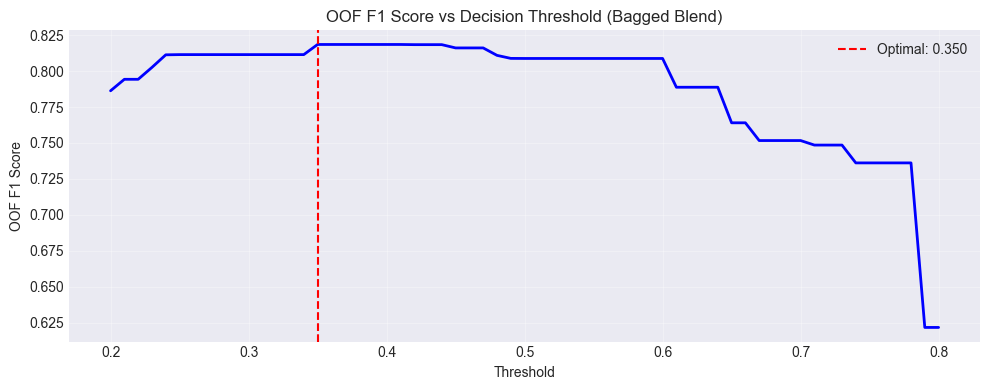

In [ ]:
# ============================================================
# OOF THRESHOLD TUNING + META-STACKING (LEAKAGE-SAFE)
# ============================================================
print("=" * 60)
print("OOF THRESHOLD TUNING + META-STACKING: Leakage-Safe Spatial Fold Rebuild")
print("=" * 60)

# Use leakage-safe base matrices created right after train/val split.
X_full_base = pd.concat([X_train_base, X_val_base], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)
X_test_blend_base = X_test_base.reset_index(drop=True)

ensemble_seeds = ENSEMBLE_SEEDS
ensemble_models = []
oof_pred_sum = np.zeros(len(X_full_base), dtype=float)
oof_pred_count = np.zeros(len(X_full_base), dtype=float)
test_pred_sum = np.zeros(len(X_test_blend_base), dtype=float)
fold_default_f1 = []

model_names_for_oof = list(gpu_model_weights.keys())
oof_model_sum = {m: np.zeros(len(X_full_base), dtype=float) for m in model_names_for_oof}
oof_model_count = {m: np.zeros(len(X_full_base), dtype=float) for m in model_names_for_oof}
test_model_sum = {m: np.zeros(len(X_test_blend_base), dtype=float) for m in model_names_for_oof}

# Spatial block CV: cluster locations -> shuffle blocks -> GroupKFold
_coords_full = np.column_stack([X_full_base['Latitude'].values, X_full_base['Longitude'].values])
_n_blocks = 30
_spatial_kmeans = KMeans(n_clusters=_n_blocks, random_state=42, n_init=10)
_block_ids = _spatial_kmeans.fit_predict(_coords_full)

for seed in ensemble_seeds:
    _rng = np.random.default_rng(seed)
    _perm = _rng.permutation(_n_blocks)
    _block_fold = np.zeros(_n_blocks, dtype=int)
    for _i, _b in enumerate(_perm):
        _block_fold[_b] = _i % 5
    _fold_groups = _block_fold[_block_ids]

    _gkf = GroupKFold(n_splits=5)
    for fold, (train_idx, val_idx) in enumerate(_gkf.split(X_full_base, y_full, groups=_fold_groups), start=1):
        X_tr_base = X_full_base.iloc[train_idx].reset_index(drop=True)
        y_tr = y_full.iloc[train_idx].reset_index(drop=True)
        X_va_base = X_full_base.iloc[val_idx].reset_index(drop=True)
        y_va = y_full.iloc[val_idx].reset_index(drop=True)

        # Fold-safe spatial features from training labels only.
        train_knn_fold = compute_knn_features(X_tr_base, y_tr, X_tr_base, exclude_self=True)
        val_knn_fold = compute_knn_features(X_tr_base, y_tr, X_va_base, exclude_self=False)
        test_knn_fold = compute_knn_features(X_tr_base, y_tr, X_test_blend_base, exclude_self=False)

        query_fold = pd.concat([X_va_base, X_test_blend_base], axis=0).reset_index(drop=True)
        train_prior_fold, query_prior_fold = add_spatial_prior_features(
            X_tr_base, y_tr, query_fold, cv_splits=4, random_state=seed + fold, n_clusters=40
        )
        val_prior_fold = query_prior_fold.iloc[:len(X_va_base)].reset_index(drop=True)
        test_prior_fold = query_prior_fold.iloc[len(X_va_base):].reset_index(drop=True)

        X_tr_aug = pd.concat([
            X_tr_base.reset_index(drop=True),
            train_knn_fold.reset_index(drop=True),
            train_prior_fold.reset_index(drop=True)
        ], axis=1)
        X_va_aug = pd.concat([
            X_va_base.reset_index(drop=True),
            val_knn_fold.reset_index(drop=True),
            val_prior_fold.reset_index(drop=True)
        ], axis=1)
        X_te_aug = pd.concat([
            X_test_blend_base.reset_index(drop=True),
            test_knn_fold.reset_index(drop=True),
            test_prior_fold.reset_index(drop=True)
        ], axis=1)

        base_cols_fold = X_tr_aug.columns.tolist()
        X_tr_eng_fold = engineer_features(X_tr_aug, base_cols_fold)
        X_va_eng_fold = engineer_features(X_va_aug, base_cols_fold)
        X_te_eng_fold = engineer_features(X_te_aug, base_cols_fold)

        X_tr_eng_fold = add_temporal_climate_signals(X_tr_eng_fold)
        X_va_eng_fold = add_temporal_climate_signals(X_va_eng_fold)
        X_te_eng_fold = add_temporal_climate_signals(X_te_eng_fold)

        # Align to tuned feature list so models receive consistent columns.
        for col in eng_feature_cols:
            if col not in X_tr_eng_fold.columns:
                X_tr_eng_fold[col] = 0.0
            if col not in X_va_eng_fold.columns:
                X_va_eng_fold[col] = 0.0
            if col not in X_te_eng_fold.columns:
                X_te_eng_fold[col] = 0.0

        X_tr_eng_fold = X_tr_eng_fold[eng_feature_cols]
        X_va_eng_fold = X_va_eng_fold[eng_feature_cols]
        X_te_eng_fold = X_te_eng_fold[eng_feature_cols]

        fold_imputer = SimpleImputer(strategy='median')
        X_tr_imp_fold = pd.DataFrame(fold_imputer.fit_transform(X_tr_eng_fold), columns=eng_feature_cols)
        X_va_imp_fold = pd.DataFrame(fold_imputer.transform(X_va_eng_fold), columns=eng_feature_cols)
        X_te_imp_fold = pd.DataFrame(fold_imputer.transform(X_te_eng_fold), columns=eng_feature_cols)

        model_store = {}
        val_predictions = {}
        test_predictions = {}

        lgb_model = build_lgbm_model(random_state=seed + fold)
        lgb_model.fit(X_tr_imp_fold, y_tr)
        val_predictions['LightGBM'] = lgb_model.predict_proba(X_va_imp_fold)[:, 1]
        test_predictions['LightGBM'] = lgb_model.predict_proba(X_te_imp_fold)[:, 1]
        model_store['lgbm'] = lgb_model

        xgb_model = build_xgb_model(random_state=seed + fold)
        xgb_model.fit(X_tr_imp_fold, y_tr)
        val_predictions['XGBoost'] = xgb_model.predict_proba(X_va_imp_fold)[:, 1]
        test_predictions['XGBoost'] = xgb_model.predict_proba(X_te_imp_fold)[:, 1]
        model_store['xgb'] = xgb_model

        if 'CatBoost' in gpu_model_weights:
            cat_fold_model = build_cat_model(random_state=seed + fold)
            if cat_fold_model is not None:
                cat_fold_model.fit(X_tr_imp_fold, y_tr)
                val_predictions['CatBoost'] = cat_fold_model.predict_proba(X_va_imp_fold)[:, 1]
                test_predictions['CatBoost'] = cat_fold_model.predict_proba(X_te_imp_fold)[:, 1]
                model_store['cat'] = cat_fold_model

        blend_va = np.zeros(len(X_va_imp_fold), dtype=float)
        blend_test = np.zeros(len(X_te_imp_fold), dtype=float)
        for model_name, weight in gpu_model_weights.items():
            if model_name in val_predictions:
                blend_va += weight * val_predictions[model_name]
                blend_test += weight * test_predictions[model_name]

                oof_model_sum[model_name][val_idx] += val_predictions[model_name]
                oof_model_count[model_name][val_idx] += 1.0
                test_model_sum[model_name] += test_predictions[model_name]

        oof_pred_sum[val_idx] += blend_va
        oof_pred_count[val_idx] += 1.0
        test_pred_sum += blend_test

        fold_f1 = f1_score(y_va, (blend_va >= 0.5).astype(int))
        fold_default_f1.append(fold_f1)
        ensemble_models.append({
            'seed': seed,
            'fold': fold,
            'imputer': fold_imputer,
            **model_store,
        })
        print(f"Seed {seed} Fold {fold}: default-threshold F1 = {fold_f1:.4f}")

# Base weighted blend OOF/test probabilities
oof_pred_base = oof_pred_sum / np.maximum(oof_pred_count, 1.0)
y_proba_test_base = test_pred_sum / len(ensemble_models)
cv_scores = np.array(fold_default_f1)
default_oof_f1 = f1_score(y_full, (oof_pred_base >= 0.5).astype(int))

# Isotonic calibration for base blend
_iso_cal = IsotonicRegression(out_of_bounds='clip')
_iso_cal.fit(oof_pred_base, y_full)
oof_pred_base = _iso_cal.predict(oof_pred_base)
y_proba_test_base = _iso_cal.predict(y_proba_test_base)
print(f"Isotonic calibration applied. OOF prob range: [{oof_pred_base.min():.3f}, {oof_pred_base.max():.3f}]")

thresholds = np.arange(0.20, 0.80, 0.01)
base_scores = [f1_score(y_full, (oof_pred_base >= t).astype(int)) for t in thresholds]
base_best_idx = int(np.argmax(base_scores))
base_threshold = float(thresholds[base_best_idx])
base_f1 = float(base_scores[base_best_idx])

# Build model-level OOF probabilities for meta-stacking.
oof_model_preds = {}
test_model_preds = {}
for m in model_names_for_oof:
    valid_counts = np.maximum(oof_model_count[m], 1.0)
    oof_model_preds[m] = oof_model_sum[m] / valid_counts
    test_model_preds[m] = test_model_sum[m] / len(ensemble_models)

# Standalone XGBoost OOF benchmark
if 'XGBoost' in oof_model_preds:
    xgb_oof_pred = np.clip(oof_model_preds['XGBoost'], 1e-6, 1.0 - 1e-6)
    xgb_test_pred = np.clip(test_model_preds['XGBoost'], 1e-6, 1.0 - 1e-6)
else:
    xgb_oof_pred = oof_pred_base.copy()
    xgb_test_pred = y_proba_test_base.copy()

xgb_scores = [f1_score(y_full, (xgb_oof_pred >= t).astype(int)) for t in thresholds]
xgb_best_idx = int(np.argmax(xgb_scores))
xgb_threshold = float(thresholds[xgb_best_idx])
xgb_f1 = float(xgb_scores[xgb_best_idx])

meta_models = [m for m in model_names_for_oof if np.any(oof_model_count[m] > 0)]

def _make_meta_features(pred_dict, model_list):
    rows = len(next(iter(pred_dict.values())))
    meta = pd.DataFrame(index=np.arange(rows))
    eps = 1e-6
    for m in model_list:
        p = np.clip(pred_dict[m], eps, 1.0 - eps)
        meta[f'{m}_p'] = p
        meta[f'{m}_p2'] = p ** 2
        meta[f'{m}_logp'] = np.log(p)
        meta[f'{m}_entropy'] = -(p * np.log(p) + (1 - p) * np.log(1 - p))
    return meta

meta_oof_X = _make_meta_features(oof_model_preds, meta_models)
meta_test_X = _make_meta_features(test_model_preds, meta_models)

# CV meta-learner on OOF meta-features (no in-fold leakage).
meta_oof_pred = np.zeros(len(meta_oof_X), dtype=float)
meta_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for tr_idx, va_idx in meta_cv.split(meta_oof_X, y_full):
    meta_clf = LogisticRegression(C=1.0, class_weight='balanced', max_iter=3000, random_state=42)
    meta_clf.fit(meta_oof_X.iloc[tr_idx], y_full.iloc[tr_idx])
    meta_oof_pred[va_idx] = meta_clf.predict_proba(meta_oof_X.iloc[va_idx])[:, 1]

meta_scores = [f1_score(y_full, (meta_oof_pred >= t).astype(int)) for t in thresholds]
meta_best_idx = int(np.argmax(meta_scores))
meta_threshold = float(thresholds[meta_best_idx])
meta_f1 = float(meta_scores[meta_best_idx])

meta_model_final = LogisticRegression(C=1.0, class_weight='balanced', max_iter=3000, random_state=42)
meta_model_final.fit(meta_oof_X, y_full)
y_proba_test_meta = meta_model_final.predict_proba(meta_test_X)[:, 1]

# Three-way OOF model selection
oof_leaderboard = pd.DataFrame([
    {'Model': 'XGBoost_Standalone', 'OOF_F1': xgb_f1, 'Threshold': xgb_threshold},
    {'Model': 'BaseBlend', 'OOF_F1': base_f1, 'Threshold': base_threshold},
    {'Model': 'MetaStackedOOFBlend', 'OOF_F1': meta_f1, 'Threshold': meta_threshold},
]).sort_values('OOF_F1', ascending=False).reset_index(drop=True)

winner = oof_leaderboard.iloc[0]
best_name = str(winner['Model'])
optimal_threshold = float(winner['Threshold'])
f1_optimal = float(winner['OOF_F1'])

if best_name == 'XGBoost_Standalone':
    y_proba_test = xgb_test_pred
elif best_name == 'MetaStackedOOFBlend':
    y_proba_test = y_proba_test_meta
else:
    y_proba_test = y_proba_test_base

print("\nOOF leaderboard:")
print(oof_leaderboard.to_string(index=False))
print(f"\nSelected deployment model: {best_name}")
print(f"Blend weights: {gpu_model_weights}")
print(f"Stored ensemble members: {len(ensemble_models)}")
print(f"OOF F1 at default threshold (0.50): {default_oof_f1:.4f}")
print(f"Selected deployment threshold: {optimal_threshold:.3f}, F1={f1_optimal:.4f}")
print(f"OOF fold mean F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

plt.figure(figsize=(10, 4))
plt.plot(thresholds, base_scores, 'b-', linewidth=2, label='Base Blend OOF F1')
plt.plot(thresholds, meta_scores, 'g--', linewidth=2, label='Meta-Stack OOF F1')
plt.plot(thresholds, xgb_scores, 'm-.', linewidth=2, label='XGBoost OOF F1')
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Selected: {optimal_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('OOF F1 Score')
plt.title('OOF F1 Score vs Decision Threshold (Leakage-Safe)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

FEATURE IMPORTANCE (LightGBM)

Top 25 features:
                       feature  importance
           dist_nearest_neg_km         493
           dist_nearest_pos_km         426
             dist_diff_pos_neg         288
         spatial_prior_grid050         275
  temp_range_knn25_interaction         270
           knn_25_weighted_occ         251
         spatial_prior_grid025         249
           knn_10_weighted_occ         240
              knn_25_dist_mean         239
                     ws_dry_cv         237
              knn_50_dist_mean         235
              knn_10_dist_mean         233
               knn_5_dist_mean         223
                   aet_dry_std         204
                 aet_ppt_ratio         203
temp_spatial_prior_interaction         202
               knn_3_dist_mean         195
            knn_5_weighted_occ         191
           knn_50_weighted_occ         191
                    ws_dry_std         189
             ppt_max_min_ratio         186
      

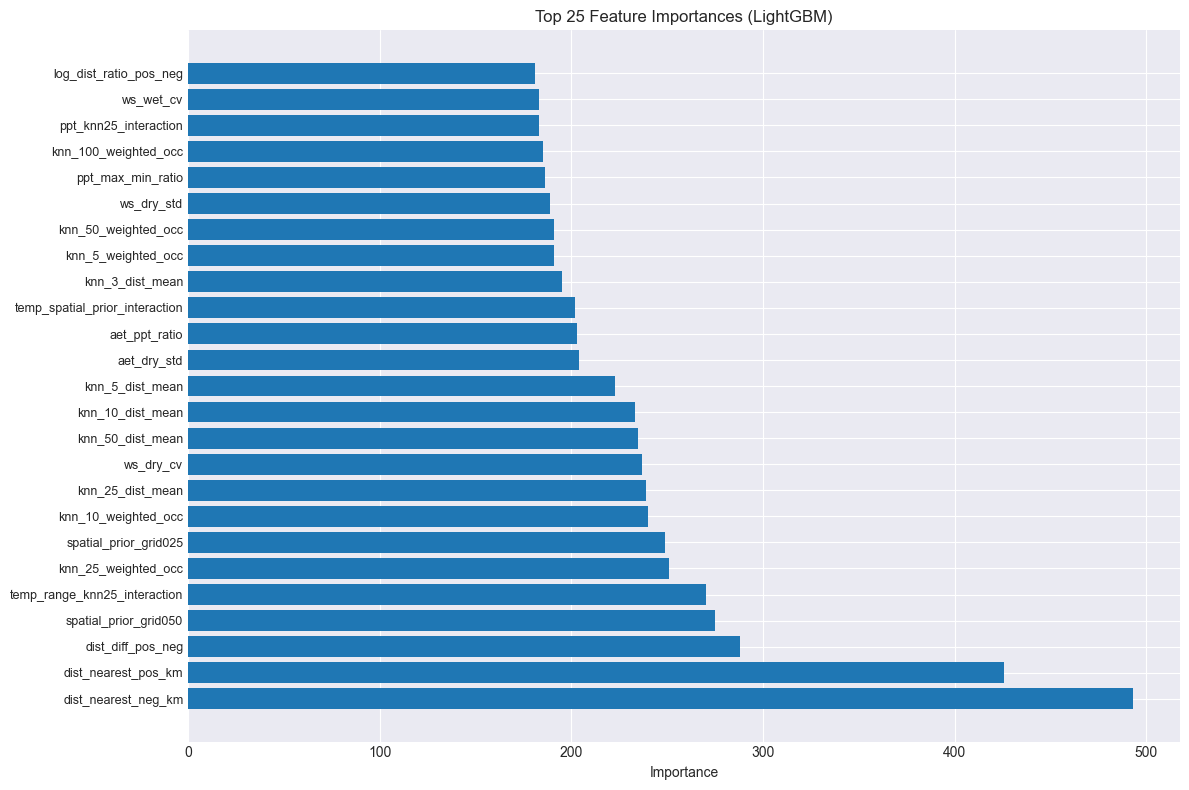

In [ ]:
# ============================================================
# FEATURE IMPORTANCE ANALYSIS
# ============================================================
print("=" * 60)
print("FEATURE IMPORTANCE (LightGBM)")
print("=" * 60)

importances = np.asarray(best_lgbm.feature_importances_)

# Prefer feature names from the fitted LightGBM model to avoid length mismatches
if hasattr(best_lgbm, 'feature_name_') and len(best_lgbm.feature_name_) == len(importances):
    fi_features = list(best_lgbm.feature_name_)
elif len(eng_feature_cols) == len(importances):
    fi_features = list(eng_feature_cols)
else:
    fi_features = [f'feature_{i}' for i in range(len(importances))]
    print(
        f"Warning: feature-name mismatch (eng_feature_cols={len(eng_feature_cols)}, "
        f"importances={len(importances)}). Using generic feature names."
    )

importance_df = pd.DataFrame({
    'feature': fi_features,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nTop 25 features:")
print(importance_df.head(25).to_string(index=False))

plt.figure(figsize=(12, 8))
top_n = min(25, len(importance_df))
plt.barh(range(top_n), importance_df['importance'].head(top_n).values)
plt.yticks(range(top_n), importance_df['feature'].head(top_n).values, fontsize=9)
plt.xlabel('Importance')
plt.title('Top 25 Feature Importances (LightGBM)')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FINAL DEPLOYMENT ARTIFACTS
# ============================================================
print("=" * 60)
print("FINAL DEPLOYMENT ARTIFACTS READY")
print("=" * 60)

# Prefer optimized final-choice selection when available, else fall back to bagged blend.
if 'final_choice_name' in globals() and 'final_choice_weights' in globals():
    deployment_name = final_choice_name
    deployment_threshold = float(final_choice_threshold)
    deployment_weights = dict(final_choice_weights)
    deployment_val_f1 = float(final_choice_val_f1)
else:
    deployment_name = best_name
    deployment_threshold = float(optimal_threshold)
    deployment_weights = dict(gpu_model_weights)
    deployment_val_f1 = float(f1_optimal)

final_model = {
    'type': 'deployment_selection',
    'name': deployment_name,
    'weights': deployment_weights,
    'threshold': deployment_threshold,
    'validation_f1': deployment_val_f1,
    'bagged_reference': {
        'name': best_name,
        'weights': gpu_model_weights,
        'threshold': optimal_threshold,
        'oof_f1': f1_optimal,
        'members': len(ensemble_models),
    },
    'feature_columns': eng_feature_cols,
}

print(f"Deployment model: {deployment_name}")
print(f"Threshold: {deployment_threshold:.3f}")
print(f"Validation F1 (selection metric): {deployment_val_f1:.4f}")
print(f"Weights: {deployment_weights}")
print(f"Bagged reference OOF F1: {f1_optimal:.4f}")

FINAL DEPLOYMENT ARTIFACTS READY
Deployment model: OptimizedWeightedBlend
Threshold: 0.450
Validation F1 (selection metric): 0.8718
Weights: {'XGBoost': 0.0038690916956529656, 'LightGBM': 0.27693209300946864, 'Stacking': 0.0017413003152918997, 'RandomForest': 0.18444335876786147, 'CatBoost': 0.533014156211725}
Bagged reference OOF F1: 0.8185


In [ ]:
# ============================================================
# GENERATE TEST PREDICTIONS AND SUBMISSION FILE
# ============================================================
print("=" * 60)
print("GENERATING FINAL SUBMISSION")
print("=" * 60)

if 'y_proba_test_final_choice' in globals() and 'final_choice_name' in globals():
    y_pred_test = (y_proba_test_final_choice >= final_choice_threshold).astype(int)
    used_model_name = final_choice_name
    used_threshold = float(final_choice_threshold)
else:
    # Fallback to bagged blend output
    y_pred_test = (y_proba_test >= optimal_threshold).astype(int)
    used_model_name = best_name
    used_threshold = float(optimal_threshold)

print(f"Deployment model: {used_model_name}")
print(f"Threshold used: {used_threshold:.3f}")
print(f"Prediction distribution:")
print(f"  No Frog (0): {np.sum(y_pred_test == 0)}")
print(f"  Frog (1):    {np.sum(y_pred_test == 1)}")

submission = pd.DataFrame({
    'ID': test_ids.values,
    'Target': y_pred_test
})

print(f"\nSubmission shape: {submission.shape}")
print(submission.head(10))

submission_file = f'Submission_Final_{used_model_name}_t{used_threshold:.2f}.csv'
submission.to_csv(submission_file, index=False)
print(f"\n✓ Submission saved: {submission_file}")

submission.to_csv('Predicted_Data.csv', index=False)
print("✓ Also saved as: Predicted_Data.csv")

GENERATING FINAL SUBMISSION
Deployment model: OptimizedWeightedBlend
Threshold used: 0.450
Prediction distribution:
  No Frog (0): 681
  Frog (1):    1319

Submission shape: (2000, 2)
             ID  Target
0  ID_TS_54240C       1
1  ID_TS_EF9635       0
2  ID_TS_4E63E6       0
3  ID_TS_FDAB8E       0
4  ID_TS_E00D49       0
5  ID_TS_A52A64       0
6  ID_TS_CFB5DB       0
7  ID_TS_CA468C       1
8  ID_TS_52FAAF       0
9  ID_TS_08039A       1

✓ Submission saved: Submission_Final_OptimizedWeightedBlend_t0.45.csv
✓ Also saved as: Predicted_Data.csv


In [ ]:
# ============================================================
# FINAL SUMMARY
# ============================================================
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(f"\nValidation Model Comparison:")
print(f"  LightGBM (Optuna):         F1 = {f1_lgbm:.4f}")
print(f"  XGBoost  (Optuna):         F1 = {f1_xgb:.4f}")
if np.isfinite(f1_cat):
    print(f"  CatBoost:                  F1 = {f1_cat:.4f}")
print(f"  Random Forest:             F1 = {f1_rf:.4f}")
print(f"  Stacking Ensemble (best):  F1 = {f1_stack:.4f}")
if 'f1_stack_lr' in globals() and 'f1_stack_lgbm' in globals():
    print(f"    - Logistic meta:         F1 = {f1_stack_lr:.4f}")
    print(f"    - LightGBM meta:         F1 = {f1_stack_lgbm:.4f}")

print(f"\nBagged Blend Reference:")
print(f"  Name: {best_name}")
print(f"  Weights: {gpu_model_weights}")
print(f"  Threshold: {optimal_threshold:.3f}")
print(f"  OOF Fold F1 Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  OOF F1 at Optimal Threshold: {f1_optimal:.4f}")
print(f"  Ensemble members: {len(ensemble_models)}")

if 'final_choice_name' in globals():
    print(f"\nSelected Final Deployment Choice:")
    print(f"  Model: {final_choice_name}")
    print(f"  Validation F1: {final_choice_val_f1:.4f}")
    print(f"  Threshold: {final_choice_threshold:.3f}")
    print(f"  Weights: {final_choice_weights}")

print(f"\nSubmission file: {submission_file}")

artifact_name = final_model['name'] if isinstance(final_model, dict) and 'name' in final_model else best_name
joblib.dump(final_model, f"final_model_{artifact_name}.pkl")
joblib.dump(eng_feature_cols, 'final_feature_cols.pkl')
print("\n✓ Model artifacts saved")
print("=" * 60)

FINAL SUMMARY

Validation Model Comparison:
  LightGBM (Optuna):         F1 = 0.8657
  XGBoost  (Optuna):         F1 = 0.8703
  CatBoost:                  F1 = 0.8524
  Random Forest:             F1 = 0.8543
  Stacking Ensemble (best):  F1 = 0.8629
    - Logistic meta:         F1 = 0.8629
    - LightGBM meta:         F1 = 0.8571

Bagged Blend Reference:
  Name: BaggedSpatialClimateBlend
  Weights: {'LightGBM': 0.335577366998232, 'XGBoost': 0.33912074864228436, 'CatBoost': 0.32530188435948376}
  Threshold: 0.350
  OOF Fold F1 Mean: 0.7862 ± 0.0615
  OOF F1 at Optimal Threshold: 0.8185
  Ensemble members: 20

Selected Final Deployment Choice:
  Model: OptimizedWeightedBlend
  Validation F1: 0.8718
  Threshold: 0.450
  Weights: {'XGBoost': 0.0038690916956529656, 'LightGBM': 0.27693209300946864, 'Stacking': 0.0017413003152918997, 'RandomForest': 0.18444335876786147, 'CatBoost': 0.533014156211725}

Submission file: Submission_Final_OptimizedWeightedBlend_t0.45.csv

✓ Model artifacts saved


## (Optional) Additional Analysis Below
The cells below are kept for reference and are NOT needed for the main pipeline above.

In [ ]:
print(f"LightGBM best F1: {study.best_value:.4f}")
print(f"XGBoost best F1: {study_xgb.best_value:.4f}")
print(f"Eng features: {len(eng_feature_cols)}")
print(f"X_train_imp shape: {X_train_imp.shape}")
print(f"X_val_imp shape: {X_val_imp.shape}")

LightGBM best F1: 0.8558
XGBoost best F1: 0.8559
Eng features: 408
X_train_imp shape: (5049, 408)
X_val_imp shape: (1263, 408)


In [ ]:
# (Legacy) Quick model comparison — already done above
print("See model comparison in the main pipeline above.")

See model comparison in the main pipeline above.


In [ ]:
# (Legacy) Feature importance — already plotted above
print("See feature importance chart in the main pipeline above.")

See feature importance chart in the main pipeline above.


---
### Legacy cells below (predictions and submissions already generated above)

In [ ]:
print("Predictions already generated. See Predicted_Data.csv")

Predictions already generated. See Predicted_Data.csv


## Section 9: Create and Save Submission File

Format predictions into the required submission format.

In [ ]:
print("Submission already saved. See above.")

Submission already saved. See above.


In [ ]:
print("Model artifacts already saved. See above.")

Model artifacts already saved. See above.


## Summary

### Pipeline Overview
1. Load training/test CSVs
2. Extract **all** TerraClimate bands (median + std) from GeoTIFF
3. Add **spatial KNN occurrence features** from nearby labeled records
4. Feature engineering: geographic encoding, hydrology and temperature ratios, aggregate stats, temporal CV
5. **Optuna** hyperparameter tuning for LightGBM and XGBoost
6. Random Forest and stacking used as comparison models
7. Build a **GPU deployment blend** from LightGBM + XGBoost
8. Use **repeated stratified folds** to create out-of-fold probabilities and average test probabilities
9. Tune the final decision threshold on the blend's OOF predictions
10. Generate submission with the optimized threshold

### Key Improvements In This Version
- Keeps the strong **spatial KNN** signal in the feature set
- Adds more **domain-driven climate interactions** and ratios
- Runs both **LightGBM and XGBoost on GPU**
- Uses a more robust **repeated fold ensemble** instead of deploying a single refit model
- Tunes threshold on **OOF blended probabilities**, which is more stable than a single validation split

---
### Legacy iteration cells below (kept for reference only, do NOT run)

In [ ]:
# Legacy: Old threshold tuning iteration (superseded by CV-based tuning above)
pass

In [ ]:
# Legacy: Old iteration 4 submission
pass

In [ ]:
# Legacy: Old iteration 5 submission
pass

In [ ]:
# Legacy: Old SMOTE iteration
pass

In [ ]:
# Legacy: Old SMOTE submission
pass